# **DAY 1 - Understanding Dataset**

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [227]:
#Dataset Load
import pandas as pd
df= pd.read_csv("raw_jobs_2500_records.csv")

In [228]:
#Insepect Number of Records
print("Number of Rows:",df.shape[0])
print("Number of Columns:",df.shape[1])

Number of Rows: 2525
Number of Columns: 12


In [229]:
print(df.columns)

Index(['job_id', 'job_title', 'company', 'company_name', 'company_id',
       'location', 'job_description', 'keywords', 'experience', 'education',
       'salary', 'job-time'],
      dtype='object')


In [230]:
df.shape

(2525, 12)

In [231]:
df.head()

,job_id,job_title,company,company_name,company_id,location,job_description,keywords,experience,education,salary,job-time
0,JOB101812,BI Analyst,InsightWorks,InsightWorks,COM007,"Chennai, Tamil Nadu",We are looking for a BI Analyst to join Insigh...,"Tableau, SQL, Excel, Business Intelligence",2-4 Years,B.Tech / B.E.,₹2.5-4 LPA,Remote
1,JOB102215,ML Engineer,BluePeak Digital,BluePeak Digital,COM011,"Mumbai, Maharashtra",We are looking for a ML Engineer to join BlueP...,"Java, Spring Boot, SQL, REST API",8+ Years,Any Graduate,₹4-7 LPA,Remote
2,JOB100557,Financial Analyst,ByteCraft Solutions,ByteCraft Solutions,COM008,"Nagpur, Maharashtra",We are looking for a Financial Analyst to join...,"SQL, Power BI, Excel, DAX",8+ Years,Any Graduate,₹8-12 LPA,Part-Time
3,JOB101269,Data Analyst,FinEdge Technologies,FinEdge Technologies,COM006,"Pune, Maharashtra",We are looking for a Data Analyst to join FinE...,"Excel, Power BI, SQL, Data Visualization",0-1 Years,Master's Degree,₹10-16 LPA,Internship
4,JOB100757,product analyst,Quantix Analytics,Quantix Analytics,COM009,"Nagpur, Maharashtra",We are looking for a Product Analyst to join Q...,"SQL, Power BI, Excel, DAX",8+ Years,Master's Degree,₹8-12 LPA,Full-Time


In [232]:
df.dtypes

,0
job_id,object
job_title,object
company,object
company_name,object
company_id,object
location,object
job_description,object
keywords,object
experience,object
education,object


In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2525 entries, 0 to 2524
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_id           2525 non-null   object
 1   job_title        2525 non-null   object
 2   company          2525 non-null   object
 3   company_name     2513 non-null   object
 4   company_id       2525 non-null   object
 5   location         2492 non-null   object
 6   job_description  2500 non-null   object
 7   keywords         2495 non-null   object
 8   experience       2505 non-null   object
 9   education        2507 non-null   object
 10  salary           2503 non-null   object
 11  job-time         2510 non-null   object
dtypes: object(12)
memory usage: 236.8+ KB


# **DAY 2 - Data Checking**

In [234]:
#Missing value
print(df.isnull().sum())

job_id              0
job_title           0
company             0
company_name       12
company_id          0
location           33
job_description    25
keywords           30
experience         20
education          18
salary             22
job-time           15
dtype: int64


In [235]:
#Duplicate value
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Records:",duplicate_count)

Number of Duplicate Records: 25


In [236]:
#Check Job Description
print(df["job_description"].head())

0    We are looking for a BI Analyst to join Insigh...
1    We are looking for a ML Engineer to join BlueP...
2    We are looking for a Financial Analyst to join...
3    We are looking for a Data Analyst to join FinE...
4    We are looking for a Product Analyst to join Q...
Name: job_description, dtype: object


In [237]:
#Check TEXT length
df["description_length"] = df["job_description"].str.len()
print(df[["job_description","description_length"]].head())

                                     job_description  description_length
0  We are looking for a BI Analyst to join Insigh...               364.0
1  We are looking for a ML Engineer to join BlueP...               357.0
2  We are looking for a Financial Analyst to join...               359.0
3  We are looking for a Data Analyst to join FinE...               374.0
4  We are looking for a Product Analyst to join Q...               358.0


In [238]:
#Check Statistical Job-description Length
print("Average Job Description Length:",df["description_length"].mean())
print("Minimum Job Description Length:",df["description_length"].min())
print("Maximum Job Description Length:",df["description_length"].max())

Average Job Description Length: 361.5224
Minimum Job Description Length: 334.0
Maximum Job Description Length: 392.0


In [239]:
#check Relevant Columns
relevant_columns = ["job_id","job_title","company_name","location","job_description","experience","education","salary","job-time"]
print("Relevant Columns:")
print(df[relevant_columns].head())

Relevant Columns:
      job_id           job_title          company_name             location  \
0  JOB101812          BI Analyst          InsightWorks  Chennai, Tamil Nadu   
1  JOB102215         ML Engineer      BluePeak Digital  Mumbai, Maharashtra   
2  JOB100557   Financial Analyst   ByteCraft Solutions  Nagpur, Maharashtra   
3  JOB101269        Data Analyst  FinEdge Technologies    Pune, Maharashtra   
4  JOB100757    product analyst      Quantix Analytics  Nagpur, Maharashtra   

                                     job_description experience  \
0  We are looking for a BI Analyst to join Insigh...  2-4 Years   
1  We are looking for a ML Engineer to join BlueP...   8+ Years   
2  We are looking for a Financial Analyst to join...   8+ Years   
3  We are looking for a Data Analyst to join FinE...  0-1 Years   
4  We are looking for a Product Analyst to join Q...   8+ Years   

         education      salary    job-time  
0    B.Tech / B.E.  ₹2.5-4 LPA      Remote  
1     Any Grad

# **DAY 3- EXPLORATORY DATA ANALYSIS (EDA)**

In [240]:
#Day 3- Exploratory Data Analysis(EDA)
#Number of job
print("Number of Job:",len(df))

Number of Job: 2525


In [241]:
#Unique Job Titles
print("Unique Job Titles:",df["job_title"].nunique())

Unique Job Titles: 30


In [242]:
# Most common job Roles
common_job_roles = df["job_title"].value_counts().head(10)
print("Most Common Job Roles:")
print(common_job_roles)

Most Common Job Roles:
job_title
AI Engineer            182
Software Engineer      178
Product Analyst        176
Data Scientist         174
Python Developer       173
Financial Analyst      171
MIS Executive          169
BI Analyst             168
Junior Data Analyst    166
ML Engineer            164
Name: count, dtype: int64


In [243]:
#Job by Location
df["location"].value_counts().head(10)

,count
location,
"Ahmedabad, Gujarat",239
"Pune, Maharashtra",217
Delhi NCR,217
"Gurugram, Haryana",215
"Mumbai, Maharashtra",213
"Nagpur, Maharashtra",212
"Bengaluru, Karnataka",210
Remote,201
"Chennai, Tamil Nadu",194


In [244]:
#Description Length
df["description_length"]= df["job_description"].fillna("").str.len()
df[["job_description", "description_length"]].head()

,job_description,description_length
0,We are looking for a BI Analyst to join Insigh...,364
1,We are looking for a ML Engineer to join BlueP...,357
2,We are looking for a Financial Analyst to join...,359
3,We are looking for a Data Analyst to join FinE...,374
4,We are looking for a Product Analyst to join Q...,358


In [245]:
#Average description Length
average_description_length = df["description_length"].mean()
print("Average Description Length:",average_description_length)

Average Description Length: 357.9429702970297


In [246]:
#Minimum Description Length
min_description_length = df["description_length"].min()
print("Minimum Description Length:",min_description_length)

Minimum Description Length: 0


In [247]:
#maximum Description Length
max_description_length = df["description_length"].max()
print("Maximum Description Length:",max_description_length)

Maximum Description Length: 392


In [248]:
#Missing Value
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})
print(missing_summary)

                    Missing Values  Missing Percentage
job_id                           0            0.000000
job_title                        0            0.000000
company                          0            0.000000
company_name                    12            0.475248
company_id                       0            0.000000
location                        33            1.306931
job_description                 25            0.990099
keywords                        30            1.188119
experience                      20            0.792079
education                       18            0.712871
salary                          22            0.871287
job-time                        15            0.594059
description_length               0            0.000000


In [249]:
#Duplicate Records
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Records:",duplicate_count)

Number of Duplicate Records: 25


In [250]:
summary = {
    "Total Records": len(df),
    "Total Columns": len(df.columns),
    "Missing Values": df.isnull().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Average Job Description Length": df["description_length"].mean(),

}
summary_df = pd.DataFrame(summary, index=[0])
summary_df


,Total Records,Total Columns,Missing Values,Duplicate Rows,Average Job Description Length
0,2525,13,NaN,25,357.94297


# **DAY 3 - Visualization**

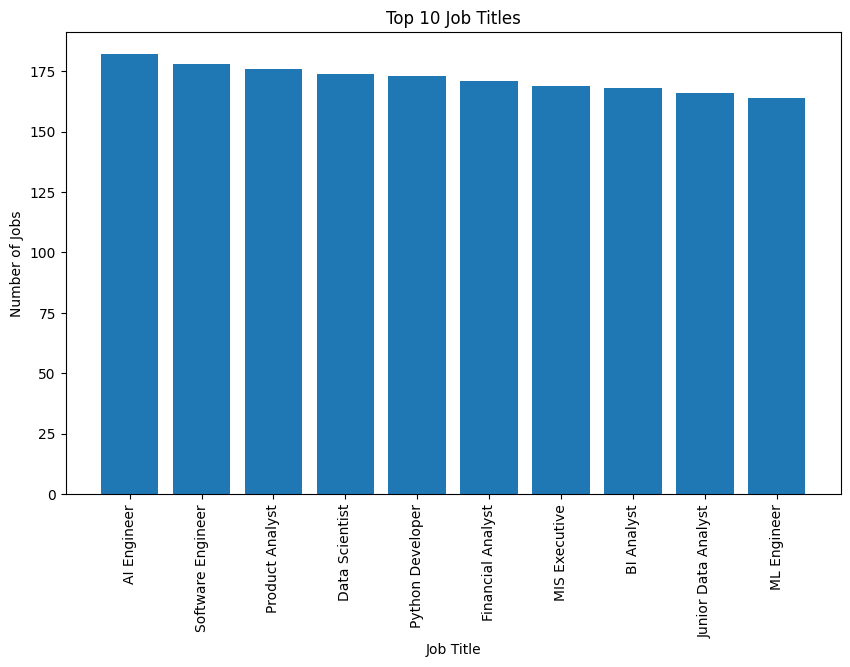

In [251]:
# Top Job Title
top_job_titles = df["job_title"].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")
plt.bar(top_job_titles.index, top_job_titles)
plt.xticks(rotation=90)
plt.show()

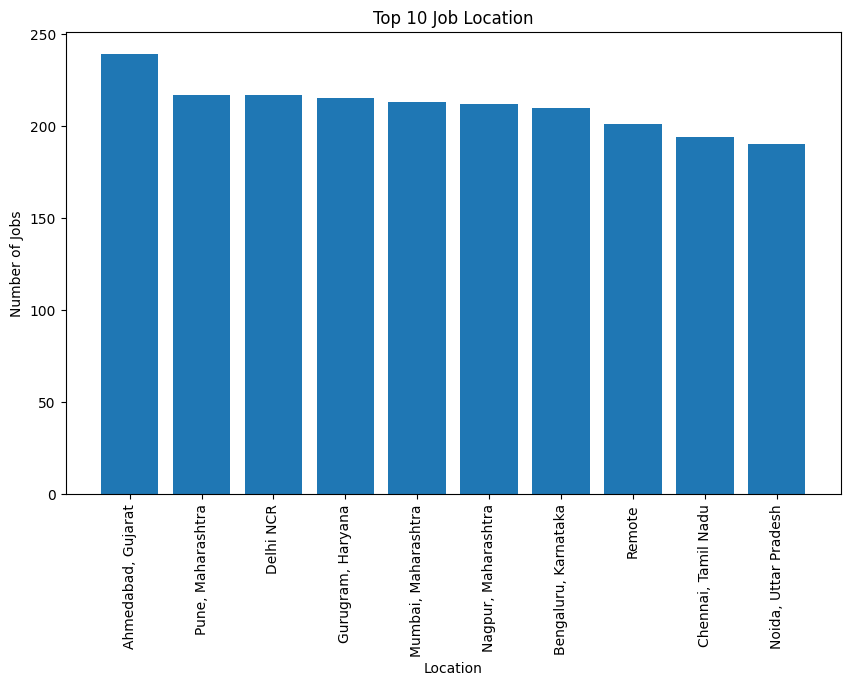

In [252]:
#Job by Location
job_by_location = df["location"].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.title("Top 10 Job Location")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.bar(job_by_location.index, job_by_location)
plt.xticks(rotation=90)
plt.show()

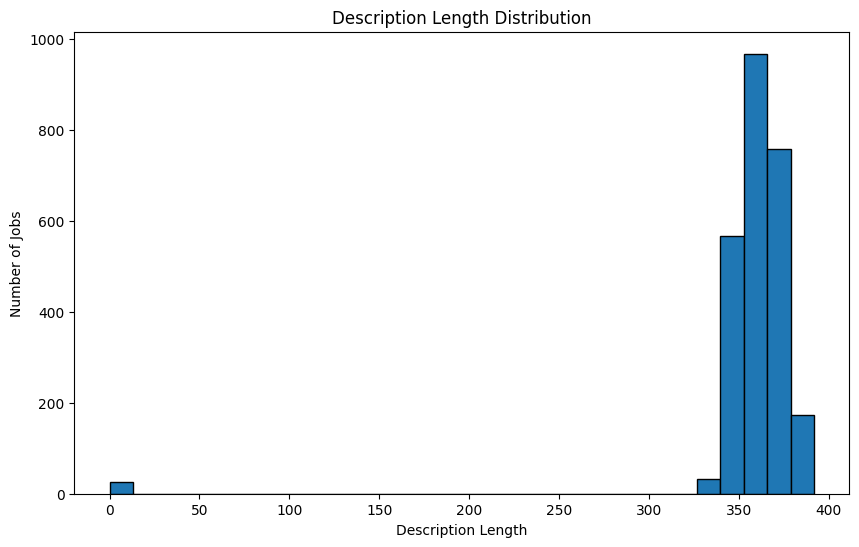

In [253]:
# Description Length
plt.figure(figsize=(10,6))
plt.title("Description Length Distribution")
plt.xlabel("Description Length")
plt.ylabel("Number of Jobs")
plt.hist(df["description_length"], bins=30, edgecolor="black")
plt.show()

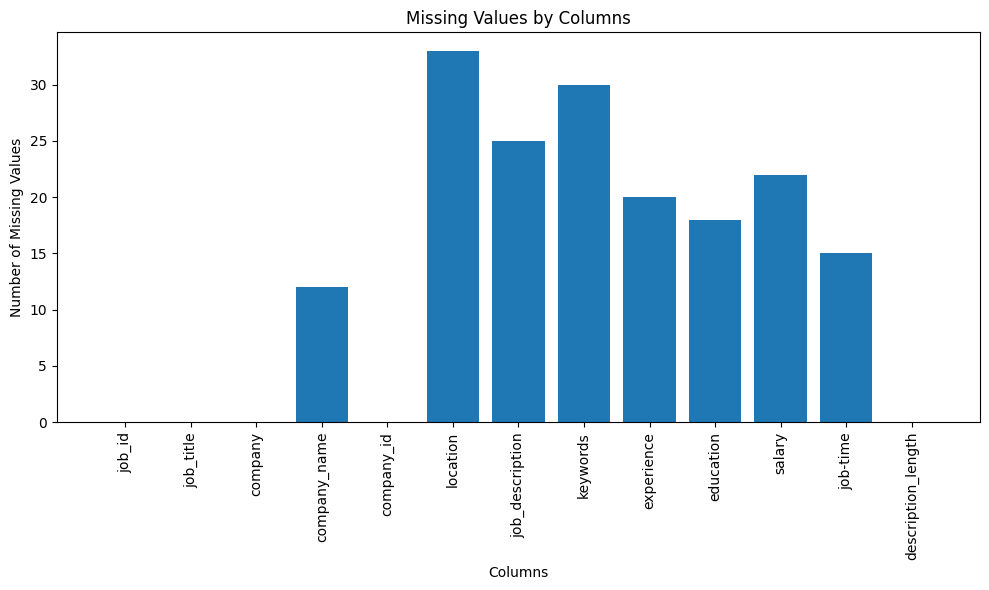

In [254]:
# Missing Values
missing_values = df.isnull().sum()
missing_counts = missing_values[missing_values > 0]
plt.figure(figsize=(10,6))
plt.title("Missing Values by Columns")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.bar(missing_values.index, missing_values)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

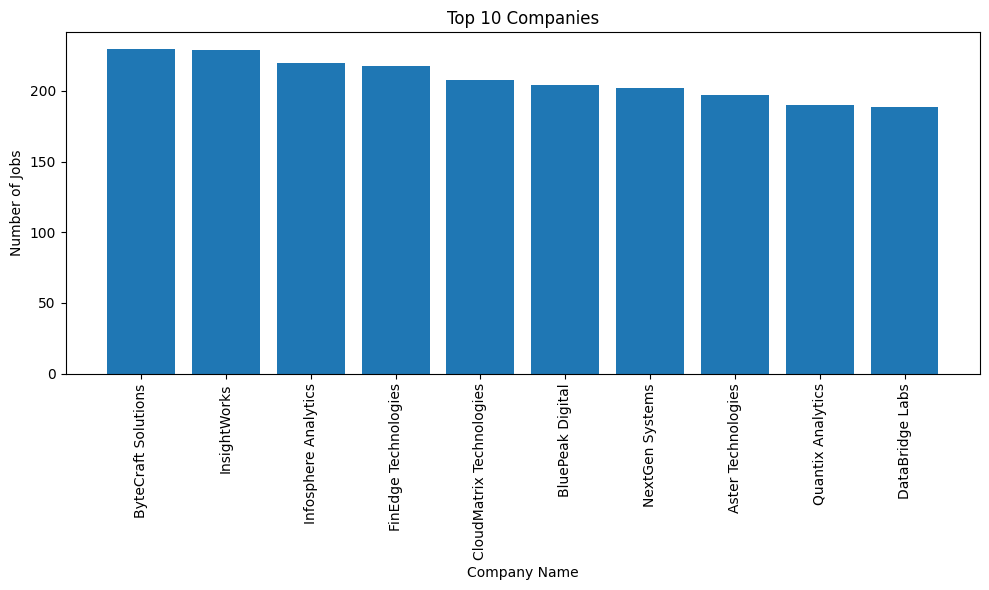

In [255]:
#Top Companies
top_companies = df["company_name"].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.title("Top 10 Companies")
plt.xlabel("Company Name")
plt.ylabel("Number of Jobs")
plt.bar(top_companies.index, top_companies)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [256]:
#EDA Summary
print("EDA SUMMARY")
print("Total Jobs:",len(df))
print("Unique Job Titles:",df["job_title"].nunique())
print("Most Common Job Roles:",common_job_roles)
print("Job by Location:",job_by_location)
print("Average Description Length:", round(df["description_length"].mean(),2))
print("Minimum Description Length:",df["description_length"].min())
print("Maximum Description Length:",df["description_length"].max())
print("Number of Duplicate Records:",df.duplicated().sum())
print("Missing Values:", df.isnull().sum().sum())

EDA SUMMARY
Total Jobs: 2525
Unique Job Titles: 30
Most Common Job Roles: job_title
AI Engineer            182
Software Engineer      178
Product Analyst        176
Data Scientist         174
Python Developer       173
Financial Analyst      171
MIS Executive          169
BI Analyst             168
Junior Data Analyst    166
ML Engineer            164
Name: count, dtype: int64
Job by Location: location
Ahmedabad, Gujarat      239
Pune, Maharashtra       217
Delhi NCR               217
Gurugram, Haryana       215
Mumbai, Maharashtra     213
Nagpur, Maharashtra     212
Bengaluru, Karnataka    210
Remote                  201
Chennai, Tamil Nadu     194
Noida, Uttar Pradesh    190
Name: count, dtype: int64
Average Description Length: 357.94
Minimum Description Length: 0
Maximum Description Length: 392
Number of Duplicate Records: 25
Missing Values: 175


# **DAY 4** **- Data Cleaning**

In [257]:
import re

In [258]:
df[["job_id","job_description"]].head(10)

,job_id,job_description
0,JOB101812,We are looking for a BI Analyst to join Insigh...
1,JOB102215,We are looking for a ML Engineer to join BlueP...
2,JOB100557,We are looking for a Financial Analyst to join...
3,JOB101269,We are looking for a Data Analyst to join FinE...
4,JOB100757,We are looking for a Product Analyst to join Q...
5,JOB101834,We are looking for a Software Engineer to join...
6,JOB101756,We are looking for a Financial Analyst to join...
7,JOB100880,We are looking for a Data Scientist to join As...
8,JOB102294,We are looking for a Product Analyst to join I...
9,JOB101368,We are looking for a MIS Executive to join Ins...


In [259]:
#Cleaning Function
import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove phone numbers
    text = re.sub(r"\b\d{10}\b", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip().lower()


In [260]:
df["clean_job_description"] = df["job_description"].apply(clean_text)

In [261]:
df[["job_description","clean_job_description"]].head(10)

,job_description,clean_job_description
0,We are looking for a BI Analyst to join Insigh...,we are looking for a bi analyst to join insigh...
1,We are looking for a ML Engineer to join BlueP...,we are looking for a ml engineer to join bluep...
2,We are looking for a Financial Analyst to join...,we are looking for a financial analyst to join...
3,We are looking for a Data Analyst to join FinE...,we are looking for a data analyst to join fine...
4,We are looking for a Product Analyst to join Q...,we are looking for a product analyst to join q...
5,We are looking for a Software Engineer to join...,we are looking for a software engineer to join...
6,We are looking for a Financial Analyst to join...,we are looking for a financial analyst to join...
7,We are looking for a Data Scientist to join As...,we are looking for a data scientist to join as...
8,We are looking for a Product Analyst to join I...,we are looking for a product analyst to join i...
9,We are looking for a MIS Executive to join Ins...,we are looking for a mis executive to join ins...


In [262]:
#Function Test
sample_text = """<p> we are hiring a python Developer!</p>
visit https://company.com
Email:hr@company.com
Call 9876543210!!!
"""
print(sample_text)
print(clean_text(sample_text))


<p> we are hiring a python Developer!</p>
visit https://company.com
Email:hr@company.com
Call 9876543210!!!

we are hiring a python developer visit call


In [263]:
df["cleaned_job_description"] = df["job_description"].apply(clean_text)
df[["job_description","cleaned_job_description"]].head(10)

,job_description,cleaned_job_description
0,We are looking for a BI Analyst to join Insigh...,we are looking for a bi analyst to join insigh...
1,We are looking for a ML Engineer to join BlueP...,we are looking for a ml engineer to join bluep...
2,We are looking for a Financial Analyst to join...,we are looking for a financial analyst to join...
3,We are looking for a Data Analyst to join FinE...,we are looking for a data analyst to join fine...
4,We are looking for a Product Analyst to join Q...,we are looking for a product analyst to join q...
5,We are looking for a Software Engineer to join...,we are looking for a software engineer to join...
6,We are looking for a Financial Analyst to join...,we are looking for a financial analyst to join...
7,We are looking for a Data Scientist to join As...,we are looking for a data scientist to join as...
8,We are looking for a Product Analyst to join I...,we are looking for a product analyst to join i...
9,We are looking for a MIS Executive to join Ins...,we are looking for a mis executive to join ins...


In [264]:
#missing values
print("Missing Values in clean_description:",df["cleaned_job_description"].isnull().sum())

Missing Values in clean_description: 0


In [265]:
#empty description check
empty_description_count = (df["cleaned_job_description"].str.strip() == "").sum()
print("Number of Empty Job Description:",empty_description_count)

Number of Empty Job Description: 0


In [266]:
#cleand text length check
df["cleaned_job_description_length"] = df["cleaned_job_description"].str.len()
print("Average Cleaned Job Description Length:",df["cleaned_job_description"])

Average Cleaned Job Description Length: 0       we are looking for a bi analyst to join insigh...
1       we are looking for a ml engineer to join bluep...
2       we are looking for a financial analyst to join...
3       we are looking for a data analyst to join fine...
4       we are looking for a product analyst to join q...
                              ...                        
2520    we are looking for a software engineer to join...
2521    we are looking for a data analyst to join byte...
2522    we are looking for a product analyst to join f...
2523    we are looking for a ml engineer to join aster...
2524    we are looking for a ai engineer to join fined...
Name: cleaned_job_description, Length: 2525, dtype: object


In [267]:
#Check Remaining Text
remaining_urls = df["cleaned_job_description"].str.contains(
    r"http\S+|www\S+",
    regex=True,
    na=False
).sum()

remaining_emails = df["cleaned_job_description"].str.contains(
    r"\S+@\S+",
    regex=True,
    na=False
).sum()

remaining_html = df["cleaned_job_description"].str.contains(
    r"<[^>]+>",
    regex=True,
    na=False
).sum()

empty_descriptions = (
    df["cleaned_job_description"].str.strip() == ""
).sum()

print("Remaining URLs:", remaining_urls)
print("Remaining Emails:", remaining_emails)
print("Remaining HTML Tags:", remaining_html)
print("Empty Cleaned Descriptions:", empty_descriptions)

Remaining URLs: 0
Remaining Emails: 0
Remaining HTML Tags: 0
Empty Cleaned Descriptions: 0


In [268]:
#cleaning Summary
print("Cleaning Summary")
print("Total Jobs:",len(df))
print("original Description column:","job_description")
print("Cleaned description column:","clean_job_description")
print("Remaning URLs:",remaining_urls)
print("Remaining Emails:",remaining_emails)
print("Empty Cleaned Descriptions:",empty_description_count)
print("Average Cleaned Job Description Length:",df["cleaned_job_description_length"].mean())

Cleaning Summary
Total Jobs: 2525
original Description column: job_description
Cleaned description column: clean_job_description
Remaning URLs: 0
Remaining Emails: 0
Empty Cleaned Descriptions: 0
Average Cleaned Job Description Length: 346.34376237623763


In [269]:
df.to_csv("cleaned_jobs_dataset.csv",index=False)
print("Cleaned data saved to cleaned_job_dataset.csv")

Cleaned data saved to cleaned_job_dataset.csv


In [270]:
from google.colab import files
files.download("cleaned_jobs_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [271]:
clean_df= pd.read_csv("cleaned_jobs_dataset.csv")
print("shape:",clean_df.shape)
print("Columns:")
print(clean_df.columns.tolist())
clean_df.head()

shape: (2525, 16)
Columns:
['job_id', 'job_title', 'company', 'company_name', 'company_id', 'location', 'job_description', 'keywords', 'experience', 'education', 'salary', 'job-time', 'description_length', 'clean_job_description', 'cleaned_job_description', 'cleaned_job_description_length']


,job_id,job_title,company,company_name,company_id,location,job_description,keywords,experience,education,salary,job-time,description_length,clean_job_description,cleaned_job_description,cleaned_job_description_length
0,JOB101812,BI Analyst,InsightWorks,InsightWorks,COM007,"Chennai, Tamil Nadu",We are looking for a BI Analyst to join Insigh...,"Tableau, SQL, Excel, Business Intelligence",2-4 Years,B.Tech / B.E.,₹2.5-4 LPA,Remote,364,we are looking for a bi analyst to join insigh...,we are looking for a bi analyst to join insigh...,350
1,JOB102215,ML Engineer,BluePeak Digital,BluePeak Digital,COM011,"Mumbai, Maharashtra",We are looking for a ML Engineer to join BlueP...,"Java, Spring Boot, SQL, REST API",8+ Years,Any Graduate,₹4-7 LPA,Remote,357,we are looking for a ml engineer to join bluep...,we are looking for a ml engineer to join bluep...,345
2,JOB100557,Financial Analyst,ByteCraft Solutions,ByteCraft Solutions,COM008,"Nagpur, Maharashtra",We are looking for a Financial Analyst to join...,"SQL, Power BI, Excel, DAX",8+ Years,Any Graduate,₹8-12 LPA,Part-Time,359,we are looking for a financial analyst to join...,we are looking for a financial analyst to join...,347
3,JOB101269,Data Analyst,FinEdge Technologies,FinEdge Technologies,COM006,"Pune, Maharashtra",We are looking for a Data Analyst to join FinE...,"Excel, Power BI, SQL, Data Visualization",0-1 Years,Master's Degree,₹10-16 LPA,Internship,374,we are looking for a data analyst to join fine...,we are looking for a data analyst to join fine...,363
4,JOB100757,product analyst,Quantix Analytics,Quantix Analytics,COM009,"Nagpur, Maharashtra",We are looking for a Product Analyst to join Q...,"SQL, Power BI, Excel, DAX",8+ Years,Master's Degree,₹8-12 LPA,Full-Time,358,we are looking for a product analyst to join q...,we are looking for a product analyst to join q...,346


# **DAY 5 - Create the Skill Taxonomy**

In [272]:
#Create Master Skill Dictionary
skills = [
    "python",
    "SQL",
    "Java",
    "C++",
    "Power BI",
    "Tableau",
    "Excel",
    "AWS",
    "Azure",
    "GCP",
    "TensorFlow",
    "PyTorch",
    "Pandas",
    "NumPy",
    "Scikit-learn",
    "Spark",
    "Hadoop",
    "Docker",
    "Git"
]
print("Total Skills:", len(skills))
print(skills)

Total Skills: 19
['python', 'SQL', 'Java', 'C++', 'Power BI', 'Tableau', 'Excel', 'AWS', 'Azure', 'GCP', 'TensorFlow', 'PyTorch', 'Pandas', 'NumPy', 'Scikit-learn', 'Spark', 'Hadoop', 'Docker', 'Git']


In [273]:
skill_categories = {
    "Python": "Programming",
    "Java": "Programming",
    "C++": "Programming",

    "SQL": "Database",

    "Power BI": "Data Analytics",
    "Tableau": "Data Analytics",
    "Excel": "Data Analytics",

    "Scikit-learn": "Machine Learning",
    "TensorFlow": "Machine Learning",
    "PyTorch": "Machine Learning",

    "AWS": "Cloud",
    "Azure": "Cloud",
    "GCP": "Cloud",

    "Pandas": "Data Analytics",
    "NumPy": "Data Analytics",
    "Spark": "Data Analytics",
    "Hadoop": "Data Analytics",
    "Docker": "Cloud",
    "Kubernetes": "Cloud",
    "Git": "Programming"
}
print("Total Skill Categories:", len(skill_categories))
print(skill_categories)

Total Skill Categories: 20
{'Python': 'Programming', 'Java': 'Programming', 'C++': 'Programming', 'SQL': 'Database', 'Power BI': 'Data Analytics', 'Tableau': 'Data Analytics', 'Excel': 'Data Analytics', 'Scikit-learn': 'Machine Learning', 'TensorFlow': 'Machine Learning', 'PyTorch': 'Machine Learning', 'AWS': 'Cloud', 'Azure': 'Cloud', 'GCP': 'Cloud', 'Pandas': 'Data Analytics', 'NumPy': 'Data Analytics', 'Spark': 'Data Analytics', 'Hadoop': 'Data Analytics', 'Docker': 'Cloud', 'Kubernetes': 'Cloud', 'Git': 'Programming'}


In [274]:
#Create Taxonomy Dataframe
taxonomy_df = pd.DataFrame(skills, columns=["skill"])
taxonomy_df["category"] = taxonomy_df["skill"].map(skill_categories)
taxonomy_df

,skill,category
0,python,NaN
1,SQL,Database
2,Java,Programming
3,C++,Programming
4,Power BI,Data Analytics
5,Tableau,Data Analytics
6,Excel,Data Analytics
7,AWS,Cloud
8,Azure,Cloud
9,GCP,Cloud


In [275]:
#Create Skills Aliases
aliases = {
    "python3": "Python",
    "ms excel": "Excel",
    "postgres": "PostgreSQL",
    "postgresql": "PostgreSQL",
    "powerbi": "Power BI",
    "scikit learn": "Scikit-learn"
}

print(aliases)

{'python3': 'Python', 'ms excel': 'Excel', 'postgres': 'PostgreSQL', 'postgresql': 'PostgreSQL', 'powerbi': 'Power BI', 'scikit learn': 'Scikit-learn'}


In [276]:
#create Alias Column
taxonomy_data = [
    ["Python", "Programming", "python3"],
    ["SQL", "Database", "sql"],
    ["Power BI", "Data Analytics", "powerbi, power-bi"],
    ["PostgreSQL", "Database", "postgres, postgresql"],
    ["Excel", "Data Analytics", "ms excel"],
    ["Scikit-learn", "Machine Learning", "scikit learn"]
]

skill_taxonomy_df = pd.DataFrame(
    taxonomy_data,
    columns=["skill", "category", "aliases"]
)

skill_taxonomy_df

,skill,category,aliases
0,Python,Programming,python3
1,SQL,Database,sql
2,Power BI,Data Analytics,"powerbi, power-bi"
3,PostgreSQL,Database,"postgres, postgresql"
4,Excel,Data Analytics,ms excel
5,Scikit-learn,Machine Learning,scikit learn


In [277]:
#add skills in taxonomy
skill_taxonomy = [
    ["Python", "Programming", "python3"],
    ["SQL", "Database", "sql"],
    ["Java", "Programming", ""],
    ["C++", "Programming", ""],
    ["Power BI", "Data Analytics", "powerbi, power-bi"],
    ["Tableau", "Data Analytics", ""],
    ["Excel", "Data Analytics", "ms excel"],
    ["AWS", "Cloud", ""],
    ["Azure", "Cloud", ""],
    ["GCP", "Cloud", ""],
    ["TensorFlow", "Machine Learning", ""],
    ["PyTorch", "Machine Learning", ""],
    ["Pandas", "Data Analytics", ""],
    ["NumPy", "Data Analytics", ""],
    ["Scikit-learn", "Machine Learning", "scikit learn"],
    ["Spark", "Data Analytics", ""],
    ["Hadoop", "Data Analytics", ""],
    ["Docker", "Cloud", ""],
    ["Kubernetes", "Cloud", ""],
    ["Git", "Programming", ""],
    ["PostgreSQL", "Database", "postgres, postgresql"]
]

skill_taxonomy_df = pd.DataFrame(
    skill_taxonomy,
    columns=["skill", "category", "aliases"]
)

skill_taxonomy_df

,skill,category,aliases
0,Python,Programming,python3
1,SQL,Database,sql
2,Java,Programming,
3,C++,Programming,
4,Power BI,Data Analytics,"powerbi, power-bi"
5,Tableau,Data Analytics,
6,Excel,Data Analytics,ms excel
7,AWS,Cloud,
8,Azure,Cloud,
9,GCP,Cloud,


In [278]:
#Check taxonomy
print("Total Skills in Taxonomy:", len(skill_taxonomy_df))

Total Skills in Taxonomy: 21


In [279]:
skill_taxonomy_df["category"].value_counts()

,count
category,
Data Analytics,7
Cloud,5
Programming,4
Machine Learning,3
Database,2


In [280]:
#check Duplicate skills
print(
    "Duplicate Skills:",
    skill_taxonomy_df["skill"].duplicated().sum()
)

Duplicate Skills: 0


In [281]:
skill_taxonomy_df.to_csv("skill_taxonomy.csv", index=False)
print("skill_taxonomy.csv created successfully")

skill_taxonomy.csv created successfully


# **DAY 6 - NLP Text Preprocessing**

In [282]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [283]:
#Sample JOB Description
text = df["cleaned_job_description"].iloc[0]
print(text)

we are looking for a bi analyst to join insightworks the candidate should have experience with tableau sql excel business intelligence responsibilities include data analysis reporting dashboard creation data cleaning problem solving and collaboration with business teams candidates with 2 4 years experience and b tech b e qualification are preferred


In [284]:
#Tokenization
from nltk.tokenize import word_tokenize
tokens = word_tokenize(text)
print(tokens)

['we', 'are', 'looking', 'for', 'a', 'bi', 'analyst', 'to', 'join', 'insightworks', 'the', 'candidate', 'should', 'have', 'experience', 'with', 'tableau', 'sql', 'excel', 'business', 'intelligence', 'responsibilities', 'include', 'data', 'analysis', 'reporting', 'dashboard', 'creation', 'data', 'cleaning', 'problem', 'solving', 'and', 'collaboration', 'with', 'business', 'teams', 'candidates', 'with', '2', '4', 'years', 'experience', 'and', 'b', 'tech', 'b', 'e', 'qualification', 'are', 'preferred']


In [285]:
#Lowercasing
lower_text = text.lower()
print(lower_text)

we are looking for a bi analyst to join insightworks the candidate should have experience with tableau sql excel business intelligence responsibilities include data analysis reporting dashboard creation data cleaning problem solving and collaboration with business teams candidates with 2 4 years experience and b tech b e qualification are preferred


In [286]:
#Stopword Removal

from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
print(filtered_tokens)

['looking', 'bi', 'analyst', 'join', 'insightworks', 'candidate', 'experience', 'tableau', 'sql', 'excel', 'business', 'intelligence', 'responsibilities', 'include', 'data', 'analysis', 'reporting', 'dashboard', 'creation', 'data', 'cleaning', 'problem', 'solving', 'collaboration', 'business', 'teams', 'candidates', '2', '4', 'years', 'experience', 'b', 'tech', 'b', 'e', 'qualification', 'preferred']


In [287]:
#Lemmatization

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]
print(lemmatized_tokens)


['looking', 'bi', 'analyst', 'join', 'insightworks', 'candidate', 'experience', 'tableau', 'sql', 'excel', 'business', 'intelligence', 'responsibility', 'include', 'data', 'analysis', 'reporting', 'dashboard', 'creation', 'data', 'cleaning', 'problem', 'solving', 'collaboration', 'business', 'team', 'candidate', '2', '4', 'year', 'experience', 'b', 'tech', 'b', 'e', 'qualification', 'preferred']


In [288]:
#Stemming
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]
print(stemmed_tokens)

['look', 'bi', 'analyst', 'join', 'insightwork', 'candid', 'experi', 'tableau', 'sql', 'excel', 'busi', 'intellig', 'respons', 'includ', 'data', 'analysi', 'report', 'dashboard', 'creation', 'data', 'clean', 'problem', 'solv', 'collabor', 'busi', 'team', 'candid', '2', '4', 'year', 'experi', 'b', 'tech', 'b', 'e', 'qualif', 'prefer']


In [289]:
#Stemming vs Lemmatization Comparison
print("Lemmatized Tokens:", lemmatized_tokens)
print("Stemmed Tokens:", stemmed_tokens)


Lemmatized Tokens: ['looking', 'bi', 'analyst', 'join', 'insightworks', 'candidate', 'experience', 'tableau', 'sql', 'excel', 'business', 'intelligence', 'responsibility', 'include', 'data', 'analysis', 'reporting', 'dashboard', 'creation', 'data', 'cleaning', 'problem', 'solving', 'collaboration', 'business', 'team', 'candidate', '2', '4', 'year', 'experience', 'b', 'tech', 'b', 'e', 'qualification', 'preferred']
Stemmed Tokens: ['look', 'bi', 'analyst', 'join', 'insightwork', 'candid', 'experi', 'tableau', 'sql', 'excel', 'busi', 'intellig', 'respons', 'includ', 'data', 'analysi', 'report', 'dashboard', 'creation', 'data', 'clean', 'problem', 'solv', 'collabor', 'busi', 'team', 'candid', '2', '4', 'year', 'experi', 'b', 'tech', 'b', 'e', 'qualif', 'prefer']


In [290]:
#Stemming vs Lemmatization Comparison
comparison = list(zip(filtered_tokens, lemmatized_tokens, stemmed_tokens))
for original, stemmed, lemmatized in comparison[:20]:
    print(f"Original: {original}, Stemmed: {stemmed}, Lemmatized: {lemmatized}")

Original: looking, Stemmed: looking, Lemmatized: look
Original: bi, Stemmed: bi, Lemmatized: bi
Original: analyst, Stemmed: analyst, Lemmatized: analyst
Original: join, Stemmed: join, Lemmatized: join
Original: insightworks, Stemmed: insightworks, Lemmatized: insightwork
Original: candidate, Stemmed: candidate, Lemmatized: candid
Original: experience, Stemmed: experience, Lemmatized: experi
Original: tableau, Stemmed: tableau, Lemmatized: tableau
Original: sql, Stemmed: sql, Lemmatized: sql
Original: excel, Stemmed: excel, Lemmatized: excel
Original: business, Stemmed: business, Lemmatized: busi
Original: intelligence, Stemmed: intelligence, Lemmatized: intellig
Original: responsibilities, Stemmed: responsibility, Lemmatized: respons
Original: include, Stemmed: include, Lemmatized: includ
Original: data, Stemmed: data, Lemmatized: data
Original: analysis, Stemmed: analysis, Lemmatized: analysi
Original: reporting, Stemmed: reporting, Lemmatized: report
Original: dashboard, Stemmed: das

In [291]:
# Sentence segmentation

from nltk.tokenize import sent_tokenize
sentences = sent_tokenize(text)
for i, sentence in enumerate(sentences, start=1):
    print(f"Sentence {i}: {sentence}")

Sentence 1: we are looking for a bi analyst to join insightworks the candidate should have experience with tableau sql excel business intelligence responsibilities include data analysis reporting dashboard creation data cleaning problem solving and collaboration with business teams candidates with 2 4 years experience and b tech b e qualification are preferred


# **DAY 7 - Rule-Based Skill Extractor**

In [292]:
#Create Skill Dictionary

skills= [
    "python",
    "SQL",
    "Java",
    "C++",
    "Power BI",
    "Tableau",
    "Excel",
    "AWS",
    "Azure",
    "GCP",
    "TensorFlow"
]
print("Total Skills:",len(skills))
print(skills)

Total Skills: 11
['python', 'SQL', 'Java', 'C++', 'Power BI', 'Tableau', 'Excel', 'AWS', 'Azure', 'GCP', 'TensorFlow']


In [293]:
#Extraction Function
def extract_skills(text):
    extracted_skills = []
    for skill in skills:
        if skill.lower() in str(text).lower():
            extracted_skills.append(skill)
    return extracted_skills


In [294]:
# Sample Example
sample_text = df["cleaned_job_description"].iloc[0]
extracted_skills = extract_skills(sample_text)
print("Sample Text:", sample_text)
print("Extracted Skills:", extracted_skills)

Sample Text: we are looking for a bi analyst to join insightworks the candidate should have experience with tableau sql excel business intelligence responsibilities include data analysis reporting dashboard creation data cleaning problem solving and collaboration with business teams candidates with 2 4 years experience and b tech b e qualification are preferred
Extracted Skills: ['SQL', 'Tableau', 'Excel']


In [295]:
#Apply on all dataset
df["extracted_skills"] = df["cleaned_job_description"].apply(extract_skills)
print("Skills extraction completed")

Skills extraction completed


In [296]:
#Result check
df[["job_title", "cleaned_job_description", "extracted_skills"]].head(10)

,job_title,cleaned_job_description,extracted_skills
0,BI Analyst,we are looking for a bi analyst to join insigh...,"[SQL, Tableau, Excel]"
1,ML Engineer,we are looking for a ml engineer to join bluep...,"[SQL, Java]"
2,Financial Analyst,we are looking for a financial analyst to join...,"[SQL, Power BI, Excel]"
3,Data Analyst,we are looking for a data analyst to join fine...,"[SQL, Power BI, Excel]"
4,product analyst,we are looking for a product analyst to join q...,"[SQL, Power BI, Excel]"
5,Software Engineer,we are looking for a software engineer to join...,"[SQL, Power BI, Excel]"
6,Financial Analyst,we are looking for a financial analyst to join...,"[python, SQL, AWS]"
7,Data Scientist,we are looking for a data scientist to join as...,"[python, SQL]"
8,Product Analyst,we are looking for a product analyst to join i...,[python]
9,MIS Executive,we are looking for a mis executive to join ins...,"[python, SQL, AWS]"


In [297]:
#Skill Count Check
from collections import Counter
all_skills = [skill for skills_list in df["extracted_skills"] for skill in skills_list]
skill_counts = Counter(all_skills)
for skill_list in df["extracted_skills"]:
    for skill in skill_list:
        skill_counts[skill] += 1
print("Skill Counts:")
for skill, count in skill_counts.items():
    print(f"{skill}: {count}")

Skill Counts:
SQL: 3930
Tableau: 542
Excel: 1664
Java: 578
Power BI: 1350
python: 2928
AWS: 1118
TensorFlow: 572


In [298]:
df.to_csv("jobs_with_extracted_skills.csv", index=False)
print("jobs_with_extracted_skills.csv created successfully!")

jobs_with_extracted_skills.csv created successfully!


# **DAY 8 - Improve Extraction Using Regex and Phrase Matching**

In [299]:
# Load Dataset

import pandas as pd
import re

df = pd.read_csv("cleaned_jobs_dataset.csv")
print("shape:",df.shape)
df.head()

shape: (2525, 16)


,job_id,job_title,company,company_name,company_id,location,job_description,keywords,experience,education,salary,job-time,description_length,clean_job_description,cleaned_job_description,cleaned_job_description_length
0,JOB101812,BI Analyst,InsightWorks,InsightWorks,COM007,"Chennai, Tamil Nadu",We are looking for a BI Analyst to join Insigh...,"Tableau, SQL, Excel, Business Intelligence",2-4 Years,B.Tech / B.E.,₹2.5-4 LPA,Remote,364,we are looking for a bi analyst to join insigh...,we are looking for a bi analyst to join insigh...,350
1,JOB102215,ML Engineer,BluePeak Digital,BluePeak Digital,COM011,"Mumbai, Maharashtra",We are looking for a ML Engineer to join BlueP...,"Java, Spring Boot, SQL, REST API",8+ Years,Any Graduate,₹4-7 LPA,Remote,357,we are looking for a ml engineer to join bluep...,we are looking for a ml engineer to join bluep...,345
2,JOB100557,Financial Analyst,ByteCraft Solutions,ByteCraft Solutions,COM008,"Nagpur, Maharashtra",We are looking for a Financial Analyst to join...,"SQL, Power BI, Excel, DAX",8+ Years,Any Graduate,₹8-12 LPA,Part-Time,359,we are looking for a financial analyst to join...,we are looking for a financial analyst to join...,347
3,JOB101269,Data Analyst,FinEdge Technologies,FinEdge Technologies,COM006,"Pune, Maharashtra",We are looking for a Data Analyst to join FinE...,"Excel, Power BI, SQL, Data Visualization",0-1 Years,Master's Degree,₹10-16 LPA,Internship,374,we are looking for a data analyst to join fine...,we are looking for a data analyst to join fine...,363
4,JOB100757,product analyst,Quantix Analytics,Quantix Analytics,COM009,"Nagpur, Maharashtra",We are looking for a Product Analyst to join Q...,"SQL, Power BI, Excel, DAX",8+ Years,Master's Degree,₹8-12 LPA,Full-Time,358,we are looking for a product analyst to join q...,we are looking for a product analyst to join q...,346


In [300]:
print(df["cleaned_job_description"].head())

0    we are looking for a bi analyst to join insigh...
1    we are looking for a ml engineer to join bluep...
2    we are looking for a financial analyst to join...
3    we are looking for a data analyst to join fine...
4    we are looking for a product analyst to join q...
Name: cleaned_job_description, dtype: object


In [301]:
#Create Regex Pattern

skill_patterns = {
    "Python": r"\bpython(?:\s*3)?\b",
    "Machine Learning": r"\bmachine\s+learning\b",
    "Deep Learning": r"\bdeep\s+learning\b",
    "Natural Language Processing": r"\bnatural\s+language\s+processing\b",
    "Power BI": r"\bpower\s*bi\b",
    "Data Science": r"\bdata\s+science\b"
}

In [302]:
#Create Regex Extraction Function

def extract_skills_regex(text):
    extracted_skills = []

    if pd.isna(text):
        return extracted_skills

    text = str(text).lower()

    for skill, pattern in skill_patterns.items():
        if re.search(pattern, text, re.IGNORECASE):
            extracted_skills.append(skill)

    return extracted_skills

In [303]:
#functin Test

sample_text = """
We are looking for a Data Scientist with experience in Python 3,
Machine Learning, Deep Learning, Power BI and Data Science.
"""
print("Input:")
print(sample_text)

print("\nExtracted Skills:")
print(extract_skills_regex(sample_text))

Input:

We are looking for a Data Scientist with experience in Python 3,
Machine Learning, Deep Learning, Power BI and Data Science.


Extracted Skills:
['Python', 'Machine Learning', 'Deep Learning', 'Power BI', 'Data Science']


In [304]:
#Apply on all Dataset
df["regex_extracted_skills"] = df["cleaned_job_description"].apply(extract_skills_regex)
print("Skills extraction completed")

Skills extraction completed


In [305]:
#Result Check
df[[
    "job_title",
    "cleaned_job_description",
    "regex_extracted_skills"
]].head(10)

,job_title,cleaned_job_description,regex_extracted_skills
0,BI Analyst,we are looking for a bi analyst to join insigh...,[]
1,ML Engineer,we are looking for a ml engineer to join bluep...,[]
2,Financial Analyst,we are looking for a financial analyst to join...,[Power BI]
3,Data Analyst,we are looking for a data analyst to join fine...,[Power BI]
4,product analyst,we are looking for a product analyst to join q...,[Power BI]
5,Software Engineer,we are looking for a software engineer to join...,[Power BI]
6,Financial Analyst,we are looking for a financial analyst to join...,[Python]
7,Data Scientist,we are looking for a data scientist to join as...,[Python]
8,Product Analyst,we are looking for a product analyst to join i...,"[Python, Machine Learning]"
9,MIS Executive,we are looking for a mis executive to join ins...,[Python]


In [306]:
!pip install spacy

In [307]:
import spacy
from spacy.matcher import PhraseMatcher

In [308]:
#Load spacy Model
nlp = spacy.blank("en")

In [309]:
#Create Phrase Matcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
phrases = [
    "machine learning",
    "deep learning",
    "natural language processing",
    "power bi",
    "data science",
    "python",
    "python 3",
    "python3"
]

In [310]:
patterns = [nlp.make_doc(skill) for skill in phrases]
matcher.add("SKILLS", patterns)

In [311]:
#spaCy Extraction Function

def extract_skills_spacy(text):
    extracted_skills = []

    if pd.isna(text):
        return extracted_skills

    doc = nlp(str(text))

    matches = matcher(doc)

    for match_id, start, end in matches:
        skill = doc[start:end].text
        extracted_skills.append(skill)

    return list(set(extracted_skills))

In [312]:
#spaCy Function Test

sample_text = """
We need a candidate with Python 3, Machine Learning,
Deep Learning and Power BI experience.
"""

print("Input:")
print(sample_text)

print("\nExtracted Skills:")
print(extract_skills_spacy(sample_text))

Input:

We need a candidate with Python 3, Machine Learning,
Deep Learning and Power BI experience.


Extracted Skills:
['Machine Learning', 'Python', 'Deep Learning', 'Power BI', 'Python 3']


In [313]:
#Apply on al Dataset
df["spacy_extracted_skills"] = df["cleaned_job_description"].apply(extract_skills_spacy)
print("Skills extraction completed")

Skills extraction completed


In [314]:
#Final Result Check

df[[
    "job_title",
    "cleaned_job_description",
    "spacy_extracted_skills"
]].head(10)

,job_title,cleaned_job_description,spacy_extracted_skills
0,BI Analyst,we are looking for a bi analyst to join insigh...,[]
1,ML Engineer,we are looking for a ml engineer to join bluep...,[]
2,Financial Analyst,we are looking for a financial analyst to join...,[power bi]
3,Data Analyst,we are looking for a data analyst to join fine...,[power bi]
4,product analyst,we are looking for a product analyst to join q...,[power bi]
5,Software Engineer,we are looking for a software engineer to join...,[power bi]
6,Financial Analyst,we are looking for a financial analyst to join...,[python]
7,Data Scientist,we are looking for a data scientist to join as...,[python]
8,Product Analyst,we are looking for a product analyst to join i...,"[python, machine learning]"
9,MIS Executive,we are looking for a mis executive to join ins...,[python]


In [315]:
# Final Output

final_output = df[
    [
        "job_title",
        "regex_extracted_skills",
        "spacy_extracted_skills"
    ]
]

final_output.head(10)

,job_title,regex_extracted_skills,spacy_extracted_skills
0,BI Analyst,[],[]
1,ML Engineer,[],[]
2,Financial Analyst,[Power BI],[power bi]
3,Data Analyst,[Power BI],[power bi]
4,product analyst,[Power BI],[power bi]
5,Software Engineer,[Power BI],[power bi]
6,Financial Analyst,[Python],[python]
7,Data Scientist,[Python],[python]
8,Product Analyst,"[Python, Machine Learning]","[python, machine learning]"
9,MIS Executive,[Python],[python]


In [316]:
df.to_csv("advanced_skill_extracted_jobs.csv", index=False)
print("Advanced skill extraction completed and saved successfully,")

Advanced skill extraction completed and saved successfully,


In [317]:
df.to_csv("skill_extracted_result.csv", index=False)
print("Skill extraction completed and saved successfully")

Skill extraction completed and saved successfully


# **DAY 9 - TF-IDF Analysis**

In [318]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [319]:
df["cleaned_job_description"].head()

,cleaned_job_description
0,we are looking for a bi analyst to join insigh...
1,we are looking for a ml engineer to join bluep...
2,we are looking for a financial analyst to join...
3,we are looking for a data analyst to join fine...
4,we are looking for a product analyst to join q...


In [320]:
print(df["cleaned_job_description"].isna().sum())

25


In [321]:
df["cleaned_job_description"] = df["cleaned_job_description"].fillna("")
df["cleaned_job_description"] = df["cleaned_job_description"].astype(str)

In [322]:
#Create TF-IDF Vectorizer

vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")

In [323]:
#Apply TF-IDF

x = vectorizer.fit_transform(df["cleaned_job_description"])
print("TF-IDF Matrix Shape:",x.shape)

TF-IDF Matrix Shape: (2525, 85)


In [324]:
#Feature Names

terms = vectorizer.get_feature_names_out()
print("Total Terms:", len(terms))
print(terms[:20])

Total Terms: 85
['ai' 'analysis' 'analyst' 'analytics' 'api' 'aster' 'aws' 'bachelor'
 'bca' 'bi' 'bluepeak' 'boot' 'business' 'bytecraft' 'candidate'
 'candidates' 'cleaning' 'cloudmatrix' 'collaboration' 'creation']


In [325]:
# Highest-Scoring Terms

import numpy as np
scores= np.asarray(x.mean(axis=0)).ravel()
tfidf_keywords = pd.DataFrame(
    {"term": terms, "score": scores}
)
tfidf_keywords = tfidf_keywords.sort_values(by="score", ascending=False)

print("Top 20 TF-IDF Keywords:")
print(tfidf_keywords.head(20))

Top 20 TF-IDF Keywords:
                term     score
21              data  0.232851
31        experience  0.196019
12          business  0.115503
75               sql  0.101671
20         dashboard  0.098009
18     collaboration  0.098009
14         candidate  0.098009
15        candidates  0.098009
57         preferred  0.098009
65  responsibilities  0.098009
84             years  0.098009
72           solving  0.098009
62     qualification  0.098009
41              join  0.098009
58           problem  0.098009
64         reporting  0.098009
46           looking  0.098009
35           include  0.098009
19          creation  0.098009
16          cleaning  0.098009


In [326]:
top_20_keywords = tfidf_keywords.head(20)
top_20_keywords.to_csv("top_20_keywords.csv", index=False)
print("top_20_keywords.csv created successfully")

top_20_keywords.csv created successfully


In [327]:
#create Dictionary skills

dictionary_skills = [
    "Python",
    "SQL",
    "Power BI",
    "Tableau",
    "Excel",
    "AWS",
    "Azure",
    "GCP",
    "TensorFlow",
    "PyTorch",
    "Pandas",
    "NumPy",
    "Scikit-learn",
    "Spark",
    "Hadoop",
    "Docker",
    "Kubernetes",
    "Git"
]


In [328]:
#Dictionary Skills vs TF-IDF Keywords Compare
dictionary_skills_lower = {skill.lower() for skill in dictionary_skills} #LOwercase
tfidf_keywords_lower = set(tfidf_keywords["term"].str.lower()) #TF-IDF Keywords
common_skills = (dictionary_skills_lower.intersection(tfidf_keywords_lower))
print("Dictionary Skills Found in TF-IDF:")
print("Common Skills Found:", common_skills)

Dictionary Skills Found in TF-IDF:
Common Skills Found: {'pandas', 'tableau', 'spark', 'aws', 'excel', 'python', 'sql', 'numpy', 'tensorflow'}


In [329]:
#Comparison Count
print(
 "Number of Dictionary Skills Found:", len(common_skills)
)

Number of Dictionary Skills Found: 9


In [330]:
tfidf_keywords.to_csv("tfidf_keywords.csv", index=False)
print("tfidf_keywords.csv created successfully")

tfidf_keywords.csv created successfully


# **DAY 10 - N-Gram Analysis**

In [331]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [332]:
df["cleaned_job_description"].head()

,cleaned_job_description
0,we are looking for a bi analyst to join insigh...
1,we are looking for a ml engineer to join bluep...
2,we are looking for a financial analyst to join...
3,we are looking for a data analyst to join fine...
4,we are looking for a product analyst to join q...


In [333]:
#Create N-Gram Vectorizer
vectorizer_ngram = TfidfVectorizer(ngram_range=(1,3), stop_words="english")

In [334]:
# Create TF-IDF N-Gram Matrix
x_ngram = vectorizer_ngram.fit_transform(df["cleaned_job_description"])
print("TF-IDF N-Gram Matrix Shape:", x_ngram.shape)

TF-IDF N-Gram Matrix Shape: (2525, 445)


In [335]:
#Getting N-Gram Terms

terms_ngram = vectorizer_ngram.get_feature_names_out()
print("Total N-Gram Terms:", len(terms_ngram))
print(terms_ngram[:20])

Total N-Gram Terms: 445
['ai' 'ai engineer' 'ai engineer join' 'analysis' 'analysis reporting'
 'analysis reporting dashboard' 'analyst' 'analyst join'
 'analyst join aster' 'analyst join bluepeak' 'analyst join bytecraft'
 'analyst join cloudmatrix' 'analyst join databridge'
 'analyst join finedge' 'analyst join infosphere' 'analyst join innovexa'
 'analyst join insightworks' 'analyst join nextgen' 'analyst join quantix'
 'analyst join technova']


In [336]:
#N-Gram Score

import numpy as np
scores_ngram = np.asarray(x_ngram.mean(axis=0)).ravel()
ngram_df = pd.DataFrame(
    {"term": terms_ngram, "score": scores_ngram}
)
ngram_keywords = ngram_df.sort_values(by="score", ascending=False)
print("Top 20 N-Gram Keywords:")
print(ngram_keywords.head(20))

Top 20 N-Gram Keywords:
                             term     score
91                           data  0.111304
168                    experience  0.093773
55                       business  0.055090
396                           sql  0.048216
419              teams candidates  0.046887
418                         teams  0.046887
97          data cleaning problem  0.046887
388         solving collaboration  0.046887
5    analysis reporting dashboard  0.046887
420        teams candidates years  0.046887
78       cleaning problem solving  0.046887
82                  collaboration  0.046887
83         collaboration business  0.046887
84   collaboration business teams  0.046887
85                       creation  0.046887
86                  creation data  0.046887
387                       solving  0.046887
77               cleaning problem  0.046887
88                      dashboard  0.046887
87         creation data cleaning  0.046887


In [337]:
#Seperate the unigrams, bigrams and trigrams

unigrams = ngram_keywords[ngram_keywords["term"].str.split().str.len() == 1].head(20)
bigrams = ngram_keywords[ngram_keywords["term"].str.split().str.len() == 2].head(20)
trigrams = ngram_keywords[ngram_keywords["term"].str.split().str.len() == 3].head(20)

In [338]:
#show Top N-Grams

top_20_ngrams = ngram_df.head(20)
top_20_ngrams

,term,score
0,ai,0.012257
1,ai engineer,0.012257
2,ai engineer join,0.012257
3,analysis,0.046887
4,analysis reporting,0.046887
5,analysis reporting dashboard,0.046887
6,analyst,0.036272
7,analyst join,0.036272
8,analyst join aster,0.006600
9,analyst join bluepeak,0.007845


In [339]:
#Multi-Word Skills Identify
print("Top 10 Unigrams:")
print(unigrams)
print("\nTop 10 Bigrams:")
print(bigrams)
print("\nTop 10 Trigrams:")
print(trigrams)

Top 10 Unigrams:
                 term     score
91               data  0.111304
168        experience  0.093773
55           business  0.055090
396               sql  0.048216
418             teams  0.046887
82      collaboration  0.046887
85           creation  0.046887
387           solving  0.046887
88          dashboard  0.046887
65          candidate  0.046887
73         candidates  0.046887
76           cleaning  0.046887
436             years  0.046887
328           problem  0.046887
327         preferred  0.046887
355  responsibilities  0.046887
347     qualification  0.046887
352         reporting  0.046887
3            analysis  0.046887
263           looking  0.046887

Top 10 Bigrams:
                         term     score
419          teams candidates  0.046887
388     solving collaboration  0.046887
83     collaboration business  0.046887
86              creation data  0.046887
77           cleaning problem  0.046887
60             business teams  0.046887
66       candi

In [340]:
#compare known skills
known_skills = [
    "Python",
    "SQL",
    "Power BI",
    "Tableau",
    "Excel",
    "AWS",
    "Azure",
    "machine learning",
    "deep learning",
    "natural language processing",
    "data science",
    "TensorFlow",
    "computer vision",
    "datd analysis"
]

In [341]:
ngram_skills_matchs=[]
for skill in known_skills:
    if skill in unigrams["term"].values:
        ngram_skills_matchs.append(skill)
        print("Skills Found in N-Grams:")
        print(ngram_skills_matchs)

In [342]:
ngram_df.to_csv("ngram_keywords.csv", index=False)
print("N-Gram_keywords.csv created successfully")

N-Gram_keywords.csv created successfully


# **DAY 11- Word Embedding and semantic Similarity**

In [343]:
!pip install -q sentence-transformers

In [344]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [345]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [346]:
#Simple Semantic similarity test

text1 = "Ml"
text2 = "Machine Learning"
embeddings1 = model.encode([text1])
embeddings2 = model.encode([text2])
similarity_score = cosine_similarity(embeddings1, embeddings2)[0][0]
print("Similarity Score:", similarity_score)

Similarity Score: 0.37266365


In [347]:
skills_dictionary = [
    "python",
    "SQL",
    "Java",
    "C++",
    "Power BI",
    "Tableau",
    "Excel",
    "AWS",
    "Azure",
    "GCP",
    "TensorFlow",
    "PyTorch",
    "Pandas",
    "NumPy",
    "Scikit-learn",
    "Spark",
    "Hadoop",
    "Docker",
    "Git",
    "Machine Learning",
    "Deep Learning",
    "Natural Language Processing",
    "PostgreSQL"
]

In [348]:
#Create Skill dictionary of embeddings
skills_embeddings = model.encode(skills_dictionary)
print("Number of skill:",len(skills_dictionary))
print("Embedding shape:", skills_embeddings.shape)

Number of skill: 23
Embedding shape: (23, 384)


In [349]:
# Example of new job description
job_description = """
we are looking for a Data Scientist with experience in ml, Python, SQL, and Power BI. Knowledge of cloud platforms is preferred.
"""

In [350]:
#job deceription enbedding
job_description_embedding = model.encode([job_description])

In [351]:
#check Similarity
similarities = cosine_similarity(
    job_description_embedding,
    skills_embeddings
)

In [352]:
print(type(skills_dictionary))
print(len(skills_dictionary))
print(similarities.shape)

<class 'list'>
23
(1, 23)


In [353]:

#Result
# Convert similarity scores into 1-D array
similarity_scores = similarities.flatten()

# Create Semantic Similarity Results DataFrame
semantic_results = pd.DataFrame({
    "skill": skills_dictionary,
    "similarity_score": similarity_scores
})

# Sort by similarity score
semantic_results = semantic_results.sort_values(
    by="similarity_score",
    ascending=False
).reset_index(drop=True)

# Display top results
print("Semantic Similarity Results:")
print(semantic_results.head(10))


Semantic Similarity Results:
          skill  similarity_score
0         Azure          0.348913
1        Hadoop          0.316351
2           AWS          0.306415
3        python          0.295567
4           SQL          0.271763
5           GCP          0.258586
6        Pandas          0.245894
7       Tableau          0.239481
8  Scikit-learn          0.235546
9    TensorFlow          0.218847


In [354]:
# Identify Potential Skill
threshold = 0.20
possible_skills = semantic_results[
    semantic_results["similarity_score"] >= threshold
]
possible_skills = possible_skills["skill"].tolist()
print("Possible Skills:", possible_skills)

Possible Skills: ['Azure', 'Hadoop', 'AWS', 'python', 'SQL', 'GCP', 'Pandas', 'Tableau', 'Scikit-learn', 'TensorFlow']


# **DAY 12 - Named Entity Recognition**

In [355]:
import spacy

In [356]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 25.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [357]:
nlp = spacy.load("en_core_web_sm")

In [358]:
# Create sample text
text = """
Python is used for data analysis.
microsoft provides cloude sloutions.
AWS and Google Cloude arempopular cloud platforms.
The company is located in New york
"""

In [359]:
#Standard spaCy NER
doc = nlp(text)
for ent in doc.ents:
  print(ent.text, "->", ent.label_)

microsoft -> ORG
Google Cloude -> ORG
New york -> GPE


In [360]:
#create custom entities mapping
custom_entities = {
    "Python": "SKILL",
    "SQL": "SKILL",
    "Machine Learning": "TECHNOLOGY",
    "Power BI": "TOOL",
    "PostgreSQL": "DATABASE",
    "AWS": "CLOUD_PLATFORM",
    "Google Cloud": "CLOUD_PLATFORM"
}

In [361]:
#Apply custom entities
text = """
The candidate has experience in Python, SQL, Machine Learning,
Power BI, PostgreSQL, AWS and Google Cloud.
"""

for entity, label in custom_entities.items():
    if entity.lower() in text.lower():
        print(entity, "->", label)

Python -> SKILL
SQL -> SKILL
Machine Learning -> TECHNOLOGY
Power BI -> TOOL
PostgreSQL -> DATABASE
AWS -> CLOUD_PLATFORM
Google Cloud -> CLOUD_PLATFORM


# **DAY 13 - Machine Learning Skill Classifier**

In [362]:
#  Create Labeled training data
import pandas as pd

training_data = pd.DataFrame({
    "Text": [
        "Python",
        "Pandas",
        "NumPy",
        "Machine Learning",
        "AWS",
        "Azure",
        "Google Cloud",
        "SQL",
        "PostgreSQL",
        "MySQL",
        "Power BI",
        "Tableau",
        "Excel"
    ],

    "Label": [
        "SKILL",
        "SKILL",
        "SKILL",
        "SKILL",
        "CLOUD",
        "CLOUD",
        "CLOUD",
        "DATABASE",
        "DATABASE",
        "DATABASE",
        "BI_TOOL",
        "BI_TOOL",
        "BI_TOOL"
    ]
})

training_data

,Text,Label
0,Python,SKILL
1,Pandas,SKILL
2,NumPy,SKILL
3,Machine Learning,SKILL
4,AWS,CLOUD
5,Azure,CLOUD
6,Google Cloud,CLOUD
7,SQL,DATABASE
8,PostgreSQL,DATABASE
9,MySQL,DATABASE


In [363]:
#Check Training data

print("Dataset Shape:", training_data.shape)

print("\nLabel Distribution:")
print(training_data["Label"].value_counts())

print("\nMissing Values:")
print(training_data.isnull().sum())

Dataset Shape: (13, 2)

Label Distribution:
Label
SKILL       4
CLOUD       3
DATABASE    3
BI_TOOL     3
Name: count, dtype: int64

Missing Values:
Text     0
Label    0
dtype: int64


In [364]:
# create x & y

X = training_data["Text"]
y = training_data["Label"]

In [365]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [366]:
#TF-IDF + logistic Regression

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2)
    )),

    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

In [367]:
# Model Train
model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('classifier', LogisticRegression(max_iter=1000))])

In [368]:
# Test Predictions

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Text": X_test,
    "Actual_Label": y_test,
    "Predicted_Label": y_pred
})

results

,Text,Actual_Label,Predicted_Label
0,Python,SKILL,SKILL
9,MySQL,DATABASE,SKILL
4,AWS,CLOUD,SKILL
12,Excel,BI_TOOL,SKILL


In [369]:
# Model Accuracy

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.25

Classification Report:
              precision    recall  f1-score   support

     BI_TOOL       0.00      0.00      0.00         1
       CLOUD       0.00      0.00      0.00         1
    DATABASE       0.00      0.00      0.00         1
       SKILL       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.06      0.25      0.10         4
weighted avg       0.06      0.25      0.10         4



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [370]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

     BI_TOOL       0.00      0.00      0.00         1
       CLOUD       0.00      0.00      0.00         1
    DATABASE       0.00      0.00      0.00         1
       SKILL       0.25      1.00      0.40         1

    accuracy                           0.25         4
   macro avg       0.06      0.25      0.10         4
weighted avg       0.06      0.25      0.10         4



In [371]:
# New Skill Model Test

new_skills = [
    "Python",
    "AWS",
    "PostgreSQL",
    "Power BI",
    "Tableau"
]

predictions = model.predict(new_skills)

for skill, prediction in zip(new_skills, predictions):
    print(skill, "→", prediction)


Python → SKILL
AWS → SKILL
PostgreSQL → DATABASE
Power BI → BI_TOOL
Tableau → BI_TOOL


In [372]:
#create Complete prediction table

prediction_result = pd.DataFrame({
    "Text": new_skills,
    "Predicted_Category": predictions
})

prediction_result

,Text,Predicted_Category
0,Python,SKILL
1,AWS,SKILL
2,PostgreSQL,DATABASE
3,Power BI,BI_TOOL
4,Tableau,BI_TOOL


In [373]:
import joblib

joblib.dump(model, "skill_classifier.pkl")

print("Model saved successfully as skill_classifier.pkl")

Model saved successfully as skill_classifier.pkl


In [374]:
loaded_model = joblib.load("skill_classifier.pkl")

test_prediction = loaded_model.predict(
    ["Python"]
)

print("Prediction:", test_prediction[0])

Prediction: SKILL


# **DAY 14 - Advanced Transformer-Based Extraction**

In [375]:
!pip install -q transformers torch

In [376]:
from transformers import pipeline
import pandas as pd

In [377]:
#pretrained NER model load

ner_pipeline = pipeline(
    "ner",
    aggregation_strategy="simple"
)

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [378]:
# Create Sample job Description
text = "Experience with Python, SQL and AWS."

results = ner_pipeline(text)
print(results)

[{'entity_group': 'MISC', 'score': np.float32(0.9135594), 'word': 'Python', 'start': 16, 'end': 22}, {'entity_group': 'MISC', 'score': np.float32(0.6791191), 'word': 'SQL', 'start': 24, 'end': 27}, {'entity_group': 'MISC', 'score': np.float32(0.54898435), 'word': 'A', 'start': 32, 'end': 33}, {'entity_group': 'ORG', 'score': np.float32(0.47517568), 'word': '##WS', 'start': 33, 'end': 35}]


In [379]:
skill_dictionary = [
    "Python",
    "SQL",
    "AWS",
    "Power BI",
    "Tableau",
    "Pandas",
    "NumPy",
    "Machine Learning",
    "PostgreSQL"
]

In [380]:
# Transform + skill dictionary comparison

detected_entities = [
    item["word"].strip()
    for item in results
]

print("Transformer detected entities:")
print(detected_entities)

Transformer detected entities:
['Python', 'SQL', 'A', '##WS']


In [381]:
# check known skills

text_lower = text.lower()

matched_skills = []

for skill in skill_dictionary:
    if skill.lower() in text_lower:
        matched_skills.append(skill)

print("Matched Skills:")
print(matched_skills)

Matched Skills:
['Python', 'SQL', 'AWS']


In [382]:
# FInal Skill Output

final_output = pd.DataFrame({
    "Job Description": [text],
    "Extracted Skills": [", ".join(matched_skills)]
})

final_output

,Job Description,Extracted Skills
0,"Experience with Python, SQL and AWS.","Python, SQL, AWS"


In [383]:
# Multiple job description test

test_descriptions = [
    "Experience with Python, SQL and AWS.",
    "Strong knowledge of Power BI, Excel and Tableau.",
    "Experience with Machine Learning, Python and PostgreSQL."
]

In [384]:
# Skill extracter on each skill

all_results = []

for text in test_descriptions:

    matched_skills = []

    for skill in skill_dictionary:
        if skill.lower() in text.lower():
            matched_skills.append(skill)

    all_results.append({
        "Job Description": text,
        "Extracted Skills": ", ".join(matched_skills)
    })

transformer_skill_results = pd.DataFrame(all_results)

transformer_skill_results

,Job Description,Extracted Skills
0,"Experience with Python, SQL and AWS.","Python, SQL, AWS"
1,"Strong knowledge of Power BI, Excel and Tableau.","Power BI, Tableau"
2,"Experience with Machine Learning, Python and P...","Python, SQL, Machine Learning, PostgreSQL"


# **DAY 15 - Model Evaluation**

In [385]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

In [386]:
# Create evaluation dataset

evaluation_df = df[[
    "job_title",
    "keywords",
    "job_description"
]].copy()

evaluation_df = evaluation_df.rename(columns={
    "keywords": "Ground_Truth"
})

print("Evaluation dataset created successfully!")
print("Shape:", evaluation_df.shape)
print("\nColumns:")
print(evaluation_df.columns.tolist())

display(evaluation_df.head())

Evaluation dataset created successfully!
Shape: (2525, 3)

Columns:
['job_title', 'Ground_Truth', 'job_description']


,job_title,Ground_Truth,job_description
0,BI Analyst,"Tableau, SQL, Excel, Business Intelligence",We are looking for a BI Analyst to join Insigh...
1,ML Engineer,"Java, Spring Boot, SQL, REST API",We are looking for a ML Engineer to join BlueP...
2,Financial Analyst,"SQL, Power BI, Excel, DAX",We are looking for a Financial Analyst to join...
3,Data Analyst,"Excel, Power BI, SQL, Data Visualization",We are looking for a Data Analyst to join FinE...
4,product analyst,"SQL, Power BI, Excel, DAX",We are looking for a Product Analyst to join Q...


In [387]:
# Exiting columns check

print("Available columns:")
print(evaluation_df.columns.tolist())

print("\nMissing Values:")
print(evaluation_df.isnull().sum)

Available columns:
['job_title', 'Ground_Truth', 'job_description']

Missing Values:
<bound method DataFrame.sum of       job_title  Ground_Truth  job_description
0         False         False            False
1         False         False            False
2         False         False            False
3         False         False            False
4         False         False            False
...         ...           ...              ...
2520      False         False            False
2521      False         False            False
2522      False         False            False
2523      False         False            False
2524      False         False            False

[2525 rows x 3 columns]>


In [388]:
# Step 3: Check available skill extraction functions

functions = [
    "extract_skills_dictionary",
    "extract_skills_regex",
    "extract_skills_tfidf",
    "extract_skills_ner",
    "extract_skills_ml",
    "extract_skills_transformer"
]

for func in functions:
    print(func, "->", "DEFINED" if func in globals() else "NOT DEFINED")

extract_skills_dictionary -> NOT DEFINED
extract_skills_regex -> DEFINED
extract_skills_tfidf -> NOT DEFINED
extract_skills_ner -> NOT DEFINED
extract_skills_ml -> NOT DEFINED
extract_skills_transformer -> NOT DEFINED


In [389]:
print(df.columns.tolist())

['job_id', 'job_title', 'company', 'company_name', 'company_id', 'location', 'job_description', 'keywords', 'experience', 'education', 'salary', 'job-time', 'description_length', 'clean_job_description', 'cleaned_job_description', 'cleaned_job_description_length', 'regex_extracted_skills', 'spacy_extracted_skills']


In [390]:
print(evaluation_df.columns.tolist())

['job_title', 'Ground_Truth', 'job_description']


In [391]:
# STEP 3
# Prepare Ground Truth

evaluation_df["Ground_Truth"] = evaluation_df["Ground_Truth"].astype(str)

print("Ground Truth prepared successfully!")
display(
    evaluation_df[
        ["job_title", "Ground_Truth", "job_description"]
    ].head(10)
)

Ground Truth prepared successfully!


,job_title,Ground_Truth,job_description
0,BI Analyst,"Tableau, SQL, Excel, Business Intelligence",We are looking for a BI Analyst to join Insigh...
1,ML Engineer,"Java, Spring Boot, SQL, REST API",We are looking for a ML Engineer to join BlueP...
2,Financial Analyst,"SQL, Power BI, Excel, DAX",We are looking for a Financial Analyst to join...
3,Data Analyst,"Excel, Power BI, SQL, Data Visualization",We are looking for a Data Analyst to join FinE...
4,product analyst,"SQL, Power BI, Excel, DAX",We are looking for a Product Analyst to join Q...
5,Software Engineer,"SQL, Power BI, Excel, DAX",We are looking for a Software Engineer to join...
6,Financial Analyst,"Python, SQL, AWS, ETL",We are looking for a Financial Analyst to join...
7,Data Scientist,"Python, Pandas, NumPy, SQL",We are looking for a Data Scientist to join As...
8,Product Analyst,"Python, Pandas, Machine Learning, Scikit-learn",We are looking for a Product Analyst to join I...
9,MIS Executive,"Python, SQL, AWS, ETL",We are looking for a MIS Executive to join Ins...


In [392]:
# Check variables related to Regex

available_variables = list(globals().keys())

for name in available_variables:
    if "regex" in name.lower():
        print(name)

extract_skills_regex
regex_predict_skills
regex_summary
regex_final_metrics
regex_accuracy


In [393]:
print("Ground Truth examples:")
display(evaluation_df[["job_title", "Ground_Truth"]].head(10))

Ground Truth examples:


,job_title,Ground_Truth
0,BI Analyst,"Tableau, SQL, Excel, Business Intelligence"
1,ML Engineer,"Java, Spring Boot, SQL, REST API"
2,Financial Analyst,"SQL, Power BI, Excel, DAX"
3,Data Analyst,"Excel, Power BI, SQL, Data Visualization"
4,product analyst,"SQL, Power BI, Excel, DAX"
5,Software Engineer,"SQL, Power BI, Excel, DAX"
6,Financial Analyst,"Python, SQL, AWS, ETL"
7,Data Scientist,"Python, Pandas, NumPy, SQL"
8,Product Analyst,"Python, Pandas, Machine Learning, Scikit-learn"
9,MIS Executive,"Python, SQL, AWS, ETL"


In [394]:
# Convert Ground Truth into a clean list of skills

def clean_ground_truth(value):
    if pd.isna(value):
        return []

    return [
        skill.strip().lower()
        for skill in str(value).split(",")
        if skill.strip()
    ]

evaluation_df["Ground_Truth_List"] = evaluation_df["Ground_Truth"].apply(
    clean_ground_truth
)

display(
    evaluation_df[
        ["job_title", "Ground_Truth", "Ground_Truth_List"]
    ].head(10)
)

,job_title,Ground_Truth,Ground_Truth_List
0,BI Analyst,"Tableau, SQL, Excel, Business Intelligence","[tableau, sql, excel, business intelligence]"
1,ML Engineer,"Java, Spring Boot, SQL, REST API","[java, spring boot, sql, rest api]"
2,Financial Analyst,"SQL, Power BI, Excel, DAX","[sql, power bi, excel, dax]"
3,Data Analyst,"Excel, Power BI, SQL, Data Visualization","[excel, power bi, sql, data visualization]"
4,product analyst,"SQL, Power BI, Excel, DAX","[sql, power bi, excel, dax]"
5,Software Engineer,"SQL, Power BI, Excel, DAX","[sql, power bi, excel, dax]"
6,Financial Analyst,"Python, SQL, AWS, ETL","[python, sql, aws, etl]"
7,Data Scientist,"Python, Pandas, NumPy, SQL","[python, pandas, numpy, sql]"
8,Product Analyst,"Python, Pandas, Machine Learning, Scikit-learn","[python, pandas, machine learning, scikit-learn]"
9,MIS Executive,"Python, SQL, AWS, ETL","[python, sql, aws, etl]"


In [395]:
# Extract Ground Truth skills found in the Job Description

import re

def regex_predict_skills(description, skills):
    if pd.isna(description):
        return []

    description = str(description).lower()
    predicted = []

    for skill in skills:
        pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"

        if re.search(pattern, description):
            predicted.append(skill)

    return predicted

evaluation_df["Regex_Predicted"] = evaluation_df.apply(
    lambda row: regex_predict_skills(
        row["job_description"],
        row["Ground_Truth_List"]
    ),
    axis=1
)

display(
    evaluation_df[
        ["job_title", "Ground_Truth_List", "Regex_Predicted"]
    ].head(10)
)

,job_title,Ground_Truth_List,Regex_Predicted
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[tableau, sql, excel, business intelligence]"
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql, rest api]"
2,Financial Analyst,"[sql, power bi, excel, dax]","[sql, power bi, excel, dax]"
3,Data Analyst,"[excel, power bi, sql, data visualization]","[excel, power bi, sql, data visualization]"
4,product analyst,"[sql, power bi, excel, dax]","[sql, power bi, excel, dax]"
5,Software Engineer,"[sql, power bi, excel, dax]","[sql, power bi, excel, dax]"
6,Financial Analyst,"[python, sql, aws, etl]","[python, sql, aws, etl]"
7,Data Scientist,"[python, pandas, numpy, sql]","[python, pandas, numpy, sql]"
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[python, pandas, machine learning, scikit-learn]"
9,MIS Executive,"[python, sql, aws, etl]","[python, sql, aws, etl]"


In [396]:
# Calculate TP, FP and FN

def calculate_tp_fp_fn(actual, predicted):
    actual = set(actual)
    predicted = set(predicted)

    tp = len(actual & predicted)
    fp = len(predicted - actual)
    fn = len(actual - predicted)

    return tp, fp, fn


evaluation_df[["TP", "FP", "FN"]] = evaluation_df.apply(
    lambda row: pd.Series(
        calculate_tp_fp_fn(
            row["Ground_Truth_List"],
            row["Regex_Predicted"]
        )
    ),
    axis=1
)

print("TP, FP and FN calculated successfully!")

display(
    evaluation_df[
        ["job_title", "Ground_Truth_List", "Regex_Predicted", "TP", "FP", "FN"]
    ].head(10)
)

TP, FP and FN calculated successfully!


,job_title,Ground_Truth_List,Regex_Predicted,TP,FP,FN
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[tableau, sql, excel, business intelligence]",4,0,0
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql, rest api]",4,0,0
2,Financial Analyst,"[sql, power bi, excel, dax]","[sql, power bi, excel, dax]",4,0,0
3,Data Analyst,"[excel, power bi, sql, data visualization]","[excel, power bi, sql, data visualization]",4,0,0
4,product analyst,"[sql, power bi, excel, dax]","[sql, power bi, excel, dax]",4,0,0
5,Software Engineer,"[sql, power bi, excel, dax]","[sql, power bi, excel, dax]",4,0,0
6,Financial Analyst,"[python, sql, aws, etl]","[python, sql, aws, etl]",4,0,0
7,Data Scientist,"[python, pandas, numpy, sql]","[python, pandas, numpy, sql]",4,0,0
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[python, pandas, machine learning, scikit-learn]",4,0,0
9,MIS Executive,"[python, sql, aws, etl]","[python, sql, aws, etl]",4,0,0


In [397]:
# DAY 15 - STEP 6
# Calculate Precision, Recall and F1 Score

def calculate_metrics(row):
    tp = row["TP"]
    fp = row["FP"]
    fn = row["FN"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return pd.Series([precision, recall, f1])


evaluation_df[
    ["Precision", "Recall", "F1_Score"]
] = evaluation_df.apply(calculate_metrics, axis=1)

print("Precision, Recall and F1 Score calculated successfully!")

display(
    evaluation_df[
        [
            "job_title",
            "TP",
            "FP",
            "FN",
            "Precision",
            "Recall",
            "F1_Score"
        ]
    ].head(10)
)

Precision, Recall and F1 Score calculated successfully!


,job_title,TP,FP,FN,Precision,Recall,F1_Score
0,BI Analyst,4,0,0,1.0,1.0,1.0
1,ML Engineer,4,0,0,1.0,1.0,1.0
2,Financial Analyst,4,0,0,1.0,1.0,1.0
3,Data Analyst,4,0,0,1.0,1.0,1.0
4,product analyst,4,0,0,1.0,1.0,1.0
5,Software Engineer,4,0,0,1.0,1.0,1.0
6,Financial Analyst,4,0,0,1.0,1.0,1.0
7,Data Scientist,4,0,0,1.0,1.0,1.0
8,Product Analyst,4,0,0,1.0,1.0,1.0
9,MIS Executive,4,0,0,1.0,1.0,1.0


In [398]:
# DAY 15 - STEP 7
# Calculate overall Regex performance

overall_precision = evaluation_df["Precision"].mean()
overall_recall = evaluation_df["Recall"].mean()
overall_f1 = evaluation_df["F1_Score"].mean()

print("Overall Regex Performance")
print("Precision:", round(overall_precision, 4))
print("Recall:", round(overall_recall, 4))
print("F1 Score:", round(overall_f1, 4))

Overall Regex Performance
Precision: 0.9782
Recall: 0.9782
F1 Score: 0.9782


In [399]:
regex_summary = pd.DataFrame({
    "Method": ["Regex"],
    "Precision": [overall_precision],
    "Recall": [overall_recall],
    "F1_Score": [overall_f1]
})

display(regex_summary)

,Method,Precision,Recall,F1_Score
0,Regex,0.978218,0.978218,0.978218


In [400]:
# DAY 15 - STEP 8
# Find jobs where Regex missed some Ground Truth skills

error_cases = evaluation_df[
    evaluation_df["FN"] > 0
].copy()

print("Number of error cases:", len(error_cases))

display(
    error_cases[
        [
            "job_title",
            "Ground_Truth_List",
            "Regex_Predicted",
            "TP",
            "FP",
            "FN"
        ]
    ].head(10)
)

Number of error cases: 55


,job_title,Ground_Truth_List,Regex_Predicted,TP,FP,FN
27,Python Developer,"[python, pandas, numpy, sql]",[],0,0,4
30,Data Scientist,[nan],[],0,0,1
179,Data Analyst,[nan],[],0,0,1
244,Data Scientist,"[sql, power bi, excel, dax]",[],0,0,4
334,Python Developer,"[python, sql, aws, etl]",[],0,0,4
346,Junior Data Analyst,[nan],[],0,0,1
487,AI Engineer,"[python, sql, aws, etl]",[],0,0,4
504,Financial Analyst,"[spark, python, sql, aws]",[],0,0,4
517,Financial Analyst,[nan],[],0,0,1
581,Business Analyst,"[python, pandas, numpy, sql]",[],0,0,4


In [401]:
error_cases.to_csv(
    "regex_error_analysis.csv",
    index=False
)

print("regex_error_analysis.csv created successfully!")

regex_error_analysis.csv created successfully!


In [402]:
# Save Regex evaluation results

evaluation_df.to_csv(
    "regex_evaluation.csv",
    index=False
)

print("regex_evaluation.csv created successfully!")

regex_evaluation.csv created successfully!


In [403]:
# Verify saved file

check_df = pd.read_csv("regex_evaluation.csv")

print("Saved file shape:", check_df.shape)
print("Saved file columns:")
print(check_df.columns.tolist())

display(check_df.head())

Saved file shape: (2525, 11)
Saved file columns:
['job_title', 'Ground_Truth', 'job_description', 'Ground_Truth_List', 'Regex_Predicted', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1_Score']


,job_title,Ground_Truth,job_description,Ground_Truth_List,Regex_Predicted,TP,FP,FN,Precision,Recall,F1_Score
0,BI Analyst,"Tableau, SQL, Excel, Business Intelligence",We are looking for a BI Analyst to join Insigh...,"['tableau', 'sql', 'excel', 'business intellig...","['tableau', 'sql', 'excel', 'business intellig...",4,0,0,1.0,1.0,1.0
1,ML Engineer,"Java, Spring Boot, SQL, REST API",We are looking for a ML Engineer to join BlueP...,"['java', 'spring boot', 'sql', 'rest api']","['java', 'spring boot', 'sql', 'rest api']",4,0,0,1.0,1.0,1.0
2,Financial Analyst,"SQL, Power BI, Excel, DAX",We are looking for a Financial Analyst to join...,"['sql', 'power bi', 'excel', 'dax']","['sql', 'power bi', 'excel', 'dax']",4,0,0,1.0,1.0,1.0
3,Data Analyst,"Excel, Power BI, SQL, Data Visualization",We are looking for a Data Analyst to join FinE...,"['excel', 'power bi', 'sql', 'data visualizati...","['excel', 'power bi', 'sql', 'data visualizati...",4,0,0,1.0,1.0,1.0
4,product analyst,"SQL, Power BI, Excel, DAX",We are looking for a Product Analyst to join Q...,"['sql', 'power bi', 'excel', 'dax']","['sql', 'power bi', 'excel', 'dax']",4,0,0,1.0,1.0,1.0


In [404]:
# DAY 15 - STEP 10
# Check final evaluation columns

print("Final evaluation columns:")
print(evaluation_df.columns.tolist())

print("\nNumber of records:", len(evaluation_df))

print("\nEvaluation preview:")
display(evaluation_df.head(5))

Final evaluation columns:
['job_title', 'Ground_Truth', 'job_description', 'Ground_Truth_List', 'Regex_Predicted', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1_Score']

Number of records: 2525

Evaluation preview:


,job_title,Ground_Truth,job_description,Ground_Truth_List,Regex_Predicted,TP,FP,FN,Precision,Recall,F1_Score
0,BI Analyst,"Tableau, SQL, Excel, Business Intelligence",We are looking for a BI Analyst to join Insigh...,"[tableau, sql, excel, business intelligence]","[tableau, sql, excel, business intelligence]",4,0,0,1.0,1.0,1.0
1,ML Engineer,"Java, Spring Boot, SQL, REST API",We are looking for a ML Engineer to join BlueP...,"[java, spring boot, sql, rest api]","[java, spring boot, sql, rest api]",4,0,0,1.0,1.0,1.0
2,Financial Analyst,"SQL, Power BI, Excel, DAX",We are looking for a Financial Analyst to join...,"[sql, power bi, excel, dax]","[sql, power bi, excel, dax]",4,0,0,1.0,1.0,1.0
3,Data Analyst,"Excel, Power BI, SQL, Data Visualization",We are looking for a Data Analyst to join FinE...,"[excel, power bi, sql, data visualization]","[excel, power bi, sql, data visualization]",4,0,0,1.0,1.0,1.0
4,product analyst,"SQL, Power BI, Excel, DAX",We are looking for a Product Analyst to join Q...,"[sql, power bi, excel, dax]","[sql, power bi, excel, dax]",4,0,0,1.0,1.0,1.0


In [405]:
# DAY 15 - STEP 11
# Create final Regex metrics table

regex_final_metrics = pd.DataFrame({
    "Method": ["Regex"],
    "Precision": [round(overall_precision, 4)],
    "Recall": [round(overall_recall, 4)],
    "F1_Score": [round(overall_f1, 4)]
})

display(regex_final_metrics)

,Method,Precision,Recall,F1_Score
0,Regex,0.9782,0.9782,0.9782


In [406]:
# Save final Regex metrics

regex_final_metrics.to_csv(
    "regex_final_metrics.csv",
    index=False
)

print("regex_final_metrics.csv created successfully!")

regex_final_metrics.csv created successfully!


In [407]:
# DAY 15 - STEP 12
# Validate Regex evaluation results

print("Total records:", len(evaluation_df))

print("\nTotal TP:", evaluation_df["TP"].sum())
print("Total FP:", evaluation_df["FP"].sum())
print("Total FN:", evaluation_df["FN"].sum())

print("\nAverage Precision:", round(evaluation_df["Precision"].mean(), 4))
print("Average Recall:", round(evaluation_df["Recall"].mean(), 4))
print("Average F1 Score:", round(evaluation_df["F1_Score"].mean(), 4))

Total records: 2525

Total TP: 9880
Total FP: 0
Total FN: 130

Average Precision: 0.9782
Average Recall: 0.9782
Average F1 Score: 0.9782


In [408]:
# DAY 15 - STEP 13
# Create final evaluation file

final_evaluation = evaluation_df[
    [
        "job_title",
        "Ground_Truth",
        "Regex_Predicted",
        "TP",
        "FP",
        "FN",
        "Precision",
        "Recall",
        "F1_Score"
    ]
].copy()

print("Final evaluation table created successfully!")

display(final_evaluation.head(10))

Final evaluation table created successfully!


,job_title,Ground_Truth,Regex_Predicted,TP,FP,FN,Precision,Recall,F1_Score
0,BI Analyst,"Tableau, SQL, Excel, Business Intelligence","[tableau, sql, excel, business intelligence]",4,0,0,1.0,1.0,1.0
1,ML Engineer,"Java, Spring Boot, SQL, REST API","[java, spring boot, sql, rest api]",4,0,0,1.0,1.0,1.0
2,Financial Analyst,"SQL, Power BI, Excel, DAX","[sql, power bi, excel, dax]",4,0,0,1.0,1.0,1.0
3,Data Analyst,"Excel, Power BI, SQL, Data Visualization","[excel, power bi, sql, data visualization]",4,0,0,1.0,1.0,1.0
4,product analyst,"SQL, Power BI, Excel, DAX","[sql, power bi, excel, dax]",4,0,0,1.0,1.0,1.0
5,Software Engineer,"SQL, Power BI, Excel, DAX","[sql, power bi, excel, dax]",4,0,0,1.0,1.0,1.0
6,Financial Analyst,"Python, SQL, AWS, ETL","[python, sql, aws, etl]",4,0,0,1.0,1.0,1.0
7,Data Scientist,"Python, Pandas, NumPy, SQL","[python, pandas, numpy, sql]",4,0,0,1.0,1.0,1.0
8,Product Analyst,"Python, Pandas, Machine Learning, Scikit-learn","[python, pandas, machine learning, scikit-learn]",4,0,0,1.0,1.0,1.0
9,MIS Executive,"Python, SQL, AWS, ETL","[python, sql, aws, etl]",4,0,0,1.0,1.0,1.0


In [409]:
final_evaluation.to_csv(
    "Final_evaluation.csv",
    index=False
)

print("Final_evaluation.csv created successfully!")

Final_evaluation.csv created successfully!


In [410]:
from sklearn.metrics import accuracy_score

# Convert TP, FP, FN into actual binary labels
y_true = []
y_pred = []

for _, row in evaluation_df.iterrows():
    actual = row["Ground_Truth_List"]
    predicted = row["Regex_Predicted"]

    # Each Ground Truth skill = positive
    for skill in actual:
        y_true.append(1)
        y_pred.append(1 if skill in predicted else 0)

    # Predicted skills not present in Ground Truth = false positives
    for skill in predicted:
        if skill not in actual:
            y_true.append(0)
            y_pred.append(1)

regex_accuracy = accuracy_score(y_true, y_pred)

print("Regex Accuracy:", round(regex_accuracy, 4))

Regex Accuracy: 0.987


Confusion Matrix:
[[   0    0]
 [ 130 9880]]


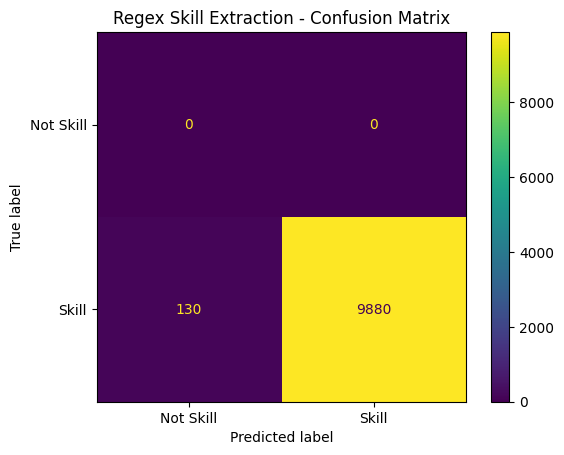

In [411]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Skill", "Skill"]
)

disp.plot()
plt.title("Regex Skill Extraction - Confusion Matrix")
plt.show()

In [412]:
# Check available skill extraction result columns

possible_methods = [
    "Dictionary",
    "Regex",
    "TF-IDF",
    "NER",
    "ML",
    "Transformer"
]

print("Available columns related to skill extraction:\n")

for col in evaluation_df.columns:
    if any(method.lower().replace("-", "") in col.lower().replace("-", "")
           for method in possible_methods):
        print("-", col)

print("\nAll evaluation columns:")
print(evaluation_df.columns.tolist())

Available columns related to skill extraction:

- Regex_Predicted

All evaluation columns:
['job_title', 'Ground_Truth', 'job_description', 'Ground_Truth_List', 'Regex_Predicted', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1_Score']


In [413]:
# Check all columns in the main dataframe
print("Main df columns:")
print(df.columns.tolist())

print("\nTotal columns:", len(df.columns))

Main df columns:
['job_id', 'job_title', 'company', 'company_name', 'company_id', 'location', 'job_description', 'keywords', 'experience', 'education', 'salary', 'job-time', 'description_length', 'clean_job_description', 'cleaned_job_description', 'cleaned_job_description_length', 'regex_extracted_skills', 'spacy_extracted_skills']

Total columns: 18


In [414]:
# Check whether the skill dictionary is available

possible_names = [
    "skills",
    "skill_dictionary",
    "skill_list",
    "skills_dictionary"
]

print("Checking skill dictionary variables...\n")

for name in possible_names:
    if name in globals():
        print(name, "FOUND")
        print(globals()[name])

Checking skill dictionary variables...

skills FOUND
['python', 'SQL', 'Java', 'C++', 'Power BI', 'Tableau', 'Excel', 'AWS', 'Azure', 'GCP', 'TensorFlow']
skill_dictionary FOUND
['Python', 'SQL', 'AWS', 'Power BI', 'Tableau', 'Pandas', 'NumPy', 'Machine Learning', 'PostgreSQL']
skill_list FOUND
['SQL', 'Tableau', 'Excel']
skills_dictionary FOUND
['python', 'SQL', 'Java', 'C++', 'Power BI', 'Tableau', 'Excel', 'AWS', 'Azure', 'GCP', 'TensorFlow', 'PyTorch', 'Pandas', 'NumPy', 'Scikit-learn', 'Spark', 'Hadoop', 'Docker', 'Git', 'Machine Learning', 'Deep Learning', 'Natural Language Processing', 'PostgreSQL']


In [415]:
# Step 20: Create Skill Dictionary

skill_dictionary = set()

for value in df["keywords"].dropna():
    skills = str(value).split(",")
    for skill in skills:
        skill = skill.strip().lower()
        if skill:
            skill_dictionary.add(skill)

skill_dictionary = sorted(skill_dictionary)

print("Skill Dictionary Created Successfully!")
print("Total unique skills:", len(skill_dictionary))
print("\nFirst 30 skills:")
print(skill_dictionary[:30])

Skill Dictionary Created Successfully!
Total unique skills: 20

First 30 skills:
['aws', 'business intelligence', 'data visualization', 'dax', 'etl', 'excel', 'java', 'machine learning', 'nlp', 'numpy', 'pandas', 'power bi', 'python', 'rest api', 'scikit-learn', 'spark', 'spring boot', 'sql', 'tableau', 'tensorflow']


In [416]:
# Step 21: Dictionary-Based Skill Extraction

def dictionary_predict_skills(description, skill_dictionary):
    if pd.isna(description):
        return []

    description = str(description).lower()
    predicted = []

    for skill in skill_dictionary:
        if skill in description:
            predicted.append(skill)

    return predicted


evaluation_df["Dictionary_Predicted"] = evaluation_df["job_description"].apply(
    lambda x: dictionary_predict_skills(x, skill_dictionary)
)

print("Dictionary prediction completed!")
print(evaluation_df[["job_title", "Dictionary_Predicted"]].head())

Dictionary prediction completed!
            job_title                          Dictionary_Predicted
0          BI Analyst  [business intelligence, excel, sql, tableau]
1         ML Engineer            [java, rest api, spring boot, sql]
2   Financial Analyst                   [dax, excel, power bi, sql]
3        Data Analyst    [data visualization, excel, power bi, sql]
4    product analyst                    [dax, excel, power bi, sql]


In [417]:
# Step 22: Calculate TP, FP and FN for Dictionary

evaluation_df[["Dictionary_TP", "Dictionary_FP", "Dictionary_FN"]] = evaluation_df.apply(
    lambda row: pd.Series(
        calculate_tp_fp_fn(
            row["Ground_Truth_List"],
            row["Dictionary_Predicted"]
        )
    ),
    axis=1
)

print("Dictionary TP, FP and FN calculated successfully!")

display(
    evaluation_df[
        ["job_title", "Ground_Truth_List", "Dictionary_Predicted",
         "Dictionary_TP", "Dictionary_FP", "Dictionary_FN"]
    ].head()
)

Dictionary TP, FP and FN calculated successfully!


,job_title,Ground_Truth_List,Dictionary_Predicted,Dictionary_TP,Dictionary_FP,Dictionary_FN
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, sql, tableau]",4,0,0
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, rest api, spring boot, sql]",4,0,0
2,Financial Analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]",4,0,0
3,Data Analyst,"[excel, power bi, sql, data visualization]","[data visualization, excel, power bi, sql]",4,0,0
4,product analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]",4,0,0


In [418]:
# Step 23: Calculate Dictionary Metrics

def calculate_dictionary_metrics(row):
    tp = row["Dictionary_TP"]
    fp = row["Dictionary_FP"]
    fn = row["Dictionary_FN"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return pd.Series([precision, recall, f1])


evaluation_df[["Dictionary_Precision",
               "Dictionary_Recall",
               "Dictionary_F1"]] = evaluation_df.apply(
    calculate_dictionary_metrics,
    axis=1
)

print("Dictionary metrics calculated successfully!")

display(
    evaluation_df[
        ["job_title",
         "Dictionary_Precision",
         "Dictionary_Recall",
         "Dictionary_F1"]
    ].head()
)

Dictionary metrics calculated successfully!


,job_title,Dictionary_Precision,Dictionary_Recall,Dictionary_F1
0,BI Analyst,1.0,1.0,1.0
1,ML Engineer,1.0,1.0,1.0
2,Financial Analyst,1.0,1.0,1.0
3,Data Analyst,1.0,1.0,1.0
4,product analyst,1.0,1.0,1.0


In [419]:
# Step 24: Overall Dictionary Metrics

dictionary_precision = evaluation_df["Dictionary_Precision"].mean()
dictionary_recall = evaluation_df["Dictionary_Recall"].mean()
dictionary_f1 = evaluation_df["Dictionary_F1"].mean()

dictionary_summary = pd.DataFrame({
    "Method": ["Dictionary"],
    "Precision": [round(dictionary_precision, 4)],
    "Recall": [round(dictionary_recall, 4)],
    "F1_Score": [round(dictionary_f1, 4)]
})

display(dictionary_summary)

,Method,Precision,Recall,F1_Score
0,Dictionary,0.9595,0.9782,0.9678


Dictionary Accuracy: 0.9529


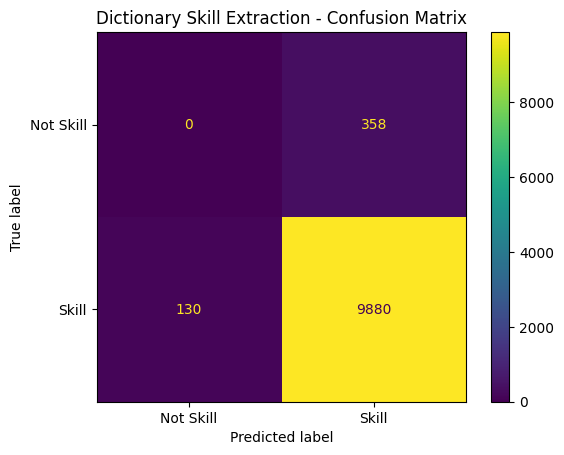

In [420]:
# Step 25: Dictionary Accuracy and Confusion Matrix

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dictionary_y_true = []
dictionary_y_pred = []

for _, row in evaluation_df.iterrows():
    actual = row["Ground_Truth_List"]
    predicted = row["Dictionary_Predicted"]

    # Actual skills
    for skill in actual:
        dictionary_y_true.append(1)
        dictionary_y_pred.append(1 if skill in predicted else 0)

    # False-positive skills
    for skill in predicted:
        if skill not in actual:
            dictionary_y_true.append(0)
            dictionary_y_pred.append(1)

dictionary_accuracy = accuracy_score(
    dictionary_y_true,
    dictionary_y_pred
)

print("Dictionary Accuracy:", round(dictionary_accuracy, 4))

# Confusion Matrix
cm_dictionary = confusion_matrix(
    dictionary_y_true,
    dictionary_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dictionary,
    display_labels=["Not Skill", "Skill"]
)

disp.plot()
plt.title("Dictionary Skill Extraction - Confusion Matrix")
plt.show()

In [421]:
# Step 26: Final Dictionary Summary

dictionary_final_summary = pd.DataFrame({
    "Method": ["Dictionary"],
    "Accuracy": [round(dictionary_accuracy, 4)],
    "Precision": [round(dictionary_precision, 4)],
    "Recall": [round(dictionary_recall, 4)],
    "F1_Score": [round(dictionary_f1, 4)]
})

display(dictionary_final_summary)

,Method,Accuracy,Precision,Recall,F1_Score
0,Dictionary,0.9529,0.9595,0.9782,0.9678


In [422]:
# Step 27: TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    evaluation_df["job_description"].fillna("")
)

tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF Vectorization completed successfully!")
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Total Features:", len(tfidf_features))
print("\nFirst 30 TF-IDF Features:")
print(tfidf_features[:30])

TF-IDF Vectorization completed successfully!
TF-IDF Matrix Shape: (2525, 445)
Total Features: 445

First 30 TF-IDF Features:
['ai' 'ai engineer' 'ai engineer join' 'analysis' 'analysis reporting'
 'analysis reporting dashboard' 'analyst' 'analyst join'
 'analyst join aster' 'analyst join bluepeak' 'analyst join bytecraft'
 'analyst join cloudmatrix' 'analyst join databridge'
 'analyst join finedge' 'analyst join infosphere' 'analyst join innovexa'
 'analyst join insightworks' 'analyst join nextgen' 'analyst join quantix'
 'analyst join technova' 'analytics' 'analytics candidate'
 'analytics candidate experience' 'api' 'api responsibilities'
 'api responsibilities include' 'aster' 'aster technologies'
 'aster technologies candidate' 'aws']


In [423]:
# Step 28: TF-IDF Based Skill Prediction

skill_dictionary_set = set(skill_dictionary)

def tfidf_predict_skills(description, vectorizer, skill_dictionary_set):
    if pd.isna(description):
        return []

    text = str(description).lower()

    # Get TF-IDF terms present in this description
    tfidf_values = vectorizer.transform([text])
    feature_names = vectorizer.get_feature_names_out()

    present_terms = set()

    for index in tfidf_values.nonzero()[1]:
        present_terms.add(feature_names[index].lower())

    # Keep only terms that are in our skill dictionary
    predicted = [
        skill for skill in skill_dictionary_set
        if skill in present_terms
    ]

    return sorted(predicted)


evaluation_df["TFIDF_Predicted"] = evaluation_df["job_description"].apply(
    lambda x: tfidf_predict_skills(
        x,
        tfidf_vectorizer,
        skill_dictionary_set
    )
)

print("TF-IDF prediction completed successfully!")

display(
    evaluation_df[
        ["job_title", "Ground_Truth_List", "TFIDF_Predicted"]
    ].head(10)
)

TF-IDF prediction completed successfully!


,job_title,Ground_Truth_List,TFIDF_Predicted
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, sql, tableau]"
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, rest api, spring boot, sql]"
2,Financial Analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]"
3,Data Analyst,"[excel, power bi, sql, data visualization]","[data visualization, excel, power bi, sql]"
4,product analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]"
5,Software Engineer,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]"
6,Financial Analyst,"[python, sql, aws, etl]","[aws, etl, python, sql]"
7,Data Scientist,"[python, pandas, numpy, sql]","[numpy, pandas, python, sql]"
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[machine learning, pandas, python]"
9,MIS Executive,"[python, sql, aws, etl]","[aws, etl, python, sql]"


In [424]:
# Step 29: Calculate TP, FP and FN for TF-IDF

evaluation_df[["TFIDF_TP", "TFIDF_FP", "TFIDF_FN"]] = evaluation_df.apply(
    lambda row: pd.Series(
        calculate_tp_fp_fn(
            row["Ground_Truth_List"],
            row["TFIDF_Predicted"]
        )
    ),
    axis=1
)

print("TF-IDF TP, FP and FN calculated successfully!")

display(
    evaluation_df[
        ["job_title",
         "Ground_Truth_List",
         "TFIDF_Predicted",
         "TFIDF_TP",
         "TFIDF_FP",
         "TFIDF_FN"]
    ].head()
)

TF-IDF TP, FP and FN calculated successfully!


,job_title,Ground_Truth_List,TFIDF_Predicted,TFIDF_TP,TFIDF_FP,TFIDF_FN
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, sql, tableau]",4,0,0
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, rest api, spring boot, sql]",4,0,0
2,Financial Analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]",4,0,0
3,Data Analyst,"[excel, power bi, sql, data visualization]","[data visualization, excel, power bi, sql]",4,0,0
4,product analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]",4,0,0


In [425]:
# Step 30: Calculate TF-IDF Metrics

def calculate_tfidf_metrics(row):
    tp = row["TFIDF_TP"]
    fp = row["TFIDF_FP"]
    fn = row["TFIDF_FN"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return pd.Series([precision, recall, f1])


evaluation_df[["TFIDF_Precision",
               "TFIDF_Recall",
               "TFIDF_F1"]] = evaluation_df.apply(
    calculate_tfidf_metrics,
    axis=1
)

print("TF-IDF metrics calculated successfully!")

display(
    evaluation_df[
        ["job_title",
         "TFIDF_Precision",
         "TFIDF_Recall",
         "TFIDF_F1"]
    ].head()
)

TF-IDF metrics calculated successfully!


,job_title,TFIDF_Precision,TFIDF_Recall,TFIDF_F1
0,BI Analyst,1.0,1.0,1.0
1,ML Engineer,1.0,1.0,1.0
2,Financial Analyst,1.0,1.0,1.0
3,Data Analyst,1.0,1.0,1.0
4,product analyst,1.0,1.0,1.0


In [426]:
# Step 31: Overall TF-IDF Metrics

tfidf_precision = evaluation_df["TFIDF_Precision"].mean()
tfidf_recall = evaluation_df["TFIDF_Recall"].mean()
tfidf_f1 = evaluation_df["TFIDF_F1"].mean()

tfidf_summary = pd.DataFrame({
    "Method": ["TF-IDF"],
    "Precision": [round(tfidf_precision, 4)],
    "Recall": [round(tfidf_recall, 4)],
    "F1_Score": [round(tfidf_f1, 4)]
})

display(tfidf_summary)

,Method,Precision,Recall,F1_Score
0,TF-IDF,0.9589,0.9498,0.9516


TF-IDF Accuracy: 0.9253


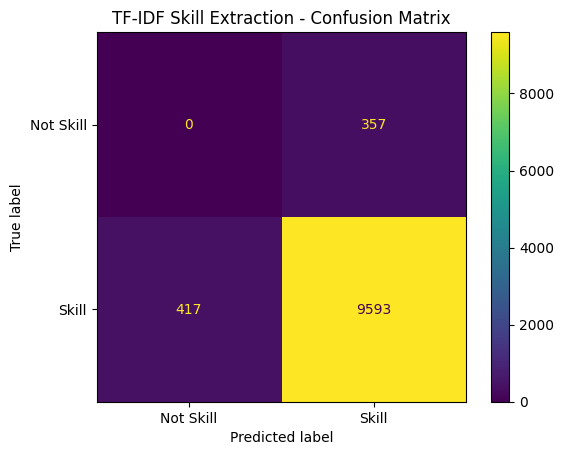

In [427]:
# Step 32: TF-IDF Accuracy and Confusion Matrix

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

tfidf_y_true = []
tfidf_y_pred = []

for _, row in evaluation_df.iterrows():
    actual = row["Ground_Truth_List"]
    predicted = row["TFIDF_Predicted"]

    # Actual skills
    for skill in actual:
        tfidf_y_true.append(1)
        tfidf_y_pred.append(1 if skill in predicted else 0)

    # False-positive skills
    for skill in predicted:
        if skill not in actual:
            tfidf_y_true.append(0)
            tfidf_y_pred.append(1)

tfidf_accuracy = accuracy_score(
    tfidf_y_true,
    tfidf_y_pred
)

print("TF-IDF Accuracy:", round(tfidf_accuracy, 4))

# Confusion Matrix
cm_tfidf = confusion_matrix(
    tfidf_y_true,
    tfidf_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tfidf,
    display_labels=["Not Skill", "Skill"]
)

disp.plot()
plt.title("TF-IDF Skill Extraction - Confusion Matrix")
plt.show()

In [428]:
# Step 33: Final TF-IDF Summary

tfidf_final_summary = pd.DataFrame({
    "Method": ["TF-IDF"],
    "Accuracy": [round(tfidf_accuracy, 4)],
    "Precision": [round(tfidf_precision, 4)],
    "Recall": [round(tfidf_recall, 4)],
    "F1_Score": [round(tfidf_f1, 4)]
})

display(tfidf_final_summary)

,Method,Accuracy,Precision,Recall,F1_Score
0,TF-IDF,0.9253,0.9589,0.9498,0.9516


In [429]:
# Check for existing NER-related variables and columns

print("NER-related columns in evaluation_df:")

ner_columns = [col for col in evaluation_df.columns if "ner" in col.lower()]

print(ner_columns)

print("\nNER-related variables:")

for name in globals():
    if "ner" in name.lower():
        print(name)

NER-related columns in evaluation_df:
[]

NER-related variables:
ner_pipeline
ner_columns
ner_predict_skills
calculate_ner_metrics
ner_precision
ner_recall
ner_f1
ner_summary
ner_y_true
ner_y_pred
ner_accuracy
cm_ner
ner_final_summary
transformer_ner


In [430]:
# Step 34: Check spaCy installation

import spacy

print("spaCy version:", spacy.__version__)

spaCy version: 3.8.16


In [431]:
# Step 35: Check spaCy NER Model

import spacy

try:
    nlp = spacy.load("en_core_web_sm")
    print("NER model loaded successfully!")
except Exception as e:
    print("NER model not installed.")
    print("Please run:")
    print("!python -m spacy download en_core_web_sm")

NER model loaded successfully!


In [432]:
# Step 36: NER-Based Skill Extraction

def ner_predict_skills(description):
    if pd.isna(description):
        return []

    doc = nlp(str(description))
    predicted = []

    for ent in doc.ents:
        entity = ent.text.strip().lower()

        # Keep entities that match our skill dictionary
        for skill in skill_dictionary:
            if entity == skill:
                predicted.append(skill)

    return sorted(set(predicted))


evaluation_df["NER_Predicted"] = evaluation_df["job_description"].apply(
    ner_predict_skills
)

print("NER prediction completed successfully!")

display(
    evaluation_df[
        ["job_title", "Ground_Truth_List", "NER_Predicted"]
    ].head(10)
)

NER prediction completed successfully!


,job_title,Ground_Truth_List,NER_Predicted
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, sql, tableau]"
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql]"
2,Financial Analyst,"[sql, power bi, excel, dax]","[excel, power bi, sql]"
3,Data Analyst,"[excel, power bi, sql, data visualization]","[data visualization, excel, power bi, sql]"
4,product analyst,"[sql, power bi, excel, dax]","[excel, power bi, sql]"
5,Software Engineer,"[sql, power bi, excel, dax]","[excel, power bi, sql]"
6,Financial Analyst,"[python, sql, aws, etl]","[aws, etl, sql]"
7,Data Scientist,"[python, pandas, numpy, sql]","[numpy, pandas, sql]"
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[machine learning, pandas]"
9,MIS Executive,"[python, sql, aws, etl]","[aws, etl, sql]"


In [433]:
# Step 37: Calculate TP, FP and FN for NER

evaluation_df[["NER_TP", "NER_FP", "NER_FN"]] = evaluation_df.apply(
    lambda row: pd.Series(
        calculate_tp_fp_fn(
            row["Ground_Truth_List"],
            row["NER_Predicted"]
        )
    ),
    axis=1
)

print("NER TP, FP and FN calculated successfully!")

display(
    evaluation_df[
        ["job_title",
         "Ground_Truth_List",
         "NER_Predicted",
         "NER_TP",
         "NER_FP",
         "NER_FN"]
    ].head()
)

NER TP, FP and FN calculated successfully!


,job_title,Ground_Truth_List,NER_Predicted,NER_TP,NER_FP,NER_FN
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, sql, tableau]",4,0,0
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql]",3,0,1
2,Financial Analyst,"[sql, power bi, excel, dax]","[excel, power bi, sql]",3,0,1
3,Data Analyst,"[excel, power bi, sql, data visualization]","[data visualization, excel, power bi, sql]",4,0,0
4,product analyst,"[sql, power bi, excel, dax]","[excel, power bi, sql]",3,0,1


In [434]:
# Step 38: Calculate NER Metrics

def calculate_ner_metrics(row):
    tp = row["NER_TP"]
    fp = row["NER_FP"]
    fn = row["NER_FN"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return pd.Series([precision, recall, f1])


evaluation_df[["NER_Precision",
               "NER_Recall",
               "NER_F1"]] = evaluation_df.apply(
    calculate_ner_metrics,
    axis=1
)

print("NER metrics calculated successfully!")

display(
    evaluation_df[
        ["job_title",
         "NER_Precision",
         "NER_Recall",
         "NER_F1"]
    ].head()
)

NER metrics calculated successfully!


,job_title,NER_Precision,NER_Recall,NER_F1
0,BI Analyst,1.0,1.00,1.000000
1,ML Engineer,1.0,0.75,0.857143
2,Financial Analyst,1.0,0.75,0.857143
3,Data Analyst,1.0,1.00,1.000000
4,product analyst,1.0,0.75,0.857143


In [435]:
# Step 39: Overall NER Metrics

ner_precision = evaluation_df["NER_Precision"].mean()
ner_recall = evaluation_df["NER_Recall"].mean()
ner_f1 = evaluation_df["NER_F1"].mean()

ner_summary = pd.DataFrame({
    "Method": ["NER"],
    "Precision": [round(ner_precision, 4)],
    "Recall": [round(ner_recall, 4)],
    "F1_Score": [round(ner_f1, 4)]
})

display(ner_summary)

,Method,Precision,Recall,F1_Score
0,NER,0.9782,0.7317,0.8265


NER Accuracy: 0.7316


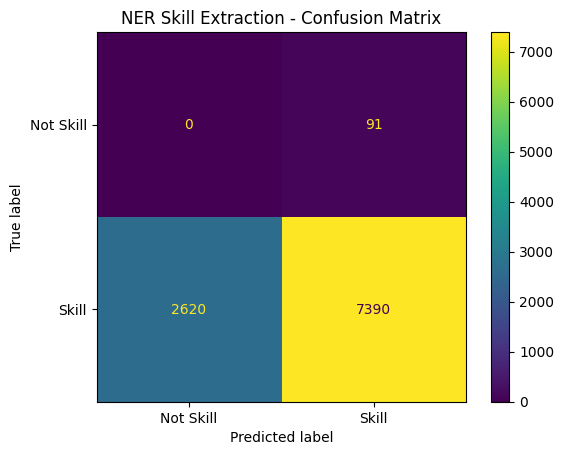

In [436]:
# Step 40: NER Accuracy and Confusion Matrix

ner_y_true = []
ner_y_pred = []

for _, row in evaluation_df.iterrows():
    actual = row["Ground_Truth_List"]
    predicted = row["NER_Predicted"]

    # Actual skills
    for skill in actual:
        ner_y_true.append(1)
        ner_y_pred.append(1 if skill in predicted else 0)

    # False-positive skills
    for skill in predicted:
        if skill not in actual:
            ner_y_true.append(0)
            ner_y_pred.append(1)

ner_accuracy = accuracy_score(
    ner_y_true,
    ner_y_pred
)

print("NER Accuracy:", round(ner_accuracy, 4))

# Confusion Matrix
cm_ner = confusion_matrix(
    ner_y_true,
    ner_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ner,
    display_labels=["Not Skill", "Skill"]
)

disp.plot()
plt.title("NER Skill Extraction - Confusion Matrix")
plt.show()

In [437]:
# Step 41: Final NER Summary

ner_final_summary = pd.DataFrame({
    "Method": ["NER"],
    "Accuracy": [round(ner_accuracy, 4)],
    "Precision": [round(ner_precision, 4)],
    "Recall": [round(ner_recall, 4)],
    "F1_Score": [round(ner_f1, 4)]
})

display(ner_final_summary)

,Method,Accuracy,Precision,Recall,F1_Score
0,NER,0.7316,0.9782,0.7317,0.8265


In [438]:
# Step 42: Prepare Data for ML Model

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

ml_text = evaluation_df["job_description"].fillna("")
ml_labels = evaluation_df["Ground_Truth_List"]

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(ml_labels)

X_train_text, X_test_text, Y_train, Y_test = train_test_split(
    ml_text,
    Y,
    test_size=0.2,
    random_state=42
)

ml_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

X_train = ml_vectorizer.fit_transform(X_train_text)
X_test = ml_vectorizer.transform(X_test_text)

print("ML data preparation completed!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of skill labels:", Y.shape[1])

ML data preparation completed!
Training samples: 2020
Testing samples: 505
Number of skill labels: 21


In [439]:
# Step 43: Train ML Model

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

ml_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    )
)

ml_model.fit(X_train, Y_train)

print("ML Model trained successfully!")

ML Model trained successfully!


In [440]:
# Step 44: Generate ML Predictions

Y_pred = ml_model.predict(X_test)

# Convert binary predictions back to skill names
ml_predictions = mlb.inverse_transform(Y_pred)

ml_prediction_map = pd.DataFrame({
    "job_description": X_test_text.values,
    "ML_Predicted": [list(skills) for skills in ml_predictions]
})

print("ML predictions generated successfully!")

display(ml_prediction_map.head(10))

ML predictions generated successfully!


,job_description,ML_Predicted
0,We are looking for a Product Analyst to join Q...,"[aws, python, spark, sql]"
1,We are looking for a Python Developer to join ...,"[data visualization, excel, power bi, sql]"
2,We are looking for a Python Developer to join ...,"[dax, excel, power bi, sql]"
3,We are looking for a BI Analyst to join Infosp...,"[dax, excel, power bi, sql]"
4,We are looking for a MIS Executive to join Inf...,"[numpy, pandas, python, sql]"
5,We are looking for a SQL Developer to join Blu...,"[aws, etl, python, sql]"
6,We are looking for a Software Engineer to join...,"[numpy, pandas, python, sql]"
7,We are looking for a MIS Executive to join Tec...,"[machine learning, nlp, python, tensorflow]"
8,We are looking for a Python Developer to join ...,"[aws, etl, python, sql]"
9,We are looking for a BI Analyst to join ByteCr...,"[machine learning, nlp, python, tensorflow]"


In [441]:
# Step 45: Calculate TP, FP and FN for ML Model

ml_evaluation = evaluation_df.loc[X_test_text.index, [
    "job_title",
    "Ground_Truth_List"
]].copy()

ml_evaluation["ML_Predicted"] = [
    list(skills) for skills in ml_predictions
]

ml_evaluation[["ML_TP", "ML_FP", "ML_FN"]] = ml_evaluation.apply(
    lambda row: pd.Series(
        calculate_tp_fp_fn(
            row["Ground_Truth_List"],
            row["ML_Predicted"]
        )
    ),
    axis=1
)

print("ML TP, FP and FN calculated successfully!")

display(
    ml_evaluation[
        ["job_title",
         "Ground_Truth_List",
         "ML_Predicted",
         "ML_TP",
         "ML_FP",
         "ML_FN"]
    ].head(10)
)

ML TP, FP and FN calculated successfully!


,job_title,Ground_Truth_List,ML_Predicted,ML_TP,ML_FP,ML_FN
1953,Product Analyst,"[spark, python, sql, aws]","[aws, python, spark, sql]",4,0,0
748,Python Developer,"[excel, power bi, sql, data visualization]","[data visualization, excel, power bi, sql]",4,0,0
194,Python Developer,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]",4,0,0
962,BI Analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]",4,0,0
1325,MIS Executive,"[python, pandas, numpy, sql]","[numpy, pandas, python, sql]",4,0,0
170,SQL Developer,"[python, sql, aws, etl]","[aws, etl, python, sql]",4,0,0
1652,Software Engineer,"[python, pandas, numpy, sql]","[numpy, pandas, python, sql]",4,0,0
647,MIS Executive,"[python, tensorflow, nlp, machine learning]","[machine learning, nlp, python, tensorflow]",4,0,0
2037,Python Developer,"[python, sql, aws, etl]","[aws, etl, python, sql]",4,0,0
1137,BI Analyst,"[python, tensorflow, nlp, machine learning]","[machine learning, nlp, python, tensorflow]",4,0,0


In [442]:
# Step 46: Calculate ML Model Metrics

def calculate_ml_metrics(row):
    tp = row["ML_TP"]
    fp = row["ML_FP"]
    fn = row["ML_FN"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return pd.Series([precision, recall, f1])


ml_evaluation[["ML_Precision",
               "ML_Recall",
               "ML_F1"]] = ml_evaluation.apply(
    calculate_ml_metrics,
    axis=1
)

print("ML Model metrics calculated successfully!")

display(
    ml_evaluation[
        ["job_title",
         "ML_Precision",
         "ML_Recall",
         "ML_F1"]
    ].head(10)
)

ML Model metrics calculated successfully!


,job_title,ML_Precision,ML_Recall,ML_F1
1953,Product Analyst,1.0,1.0,1.0
748,Python Developer,1.0,1.0,1.0
194,Python Developer,1.0,1.0,1.0
962,BI Analyst,1.0,1.0,1.0
1325,MIS Executive,1.0,1.0,1.0
170,SQL Developer,1.0,1.0,1.0
1652,Software Engineer,1.0,1.0,1.0
647,MIS Executive,1.0,1.0,1.0
2037,Python Developer,1.0,1.0,1.0
1137,BI Analyst,1.0,1.0,1.0


In [443]:
# Step 47: Overall ML Model Metrics

ml_precision = ml_evaluation["ML_Precision"].mean()
ml_recall = ml_evaluation["ML_Recall"].mean()
ml_f1 = ml_evaluation["ML_F1"].mean()

ml_summary = pd.DataFrame({
    "Method": ["ML"],
    "Precision": [round(ml_precision, 4)],
    "Recall": [round(ml_recall, 4)],
    "F1_Score": [round(ml_f1, 4)]
})

display(ml_summary)

,Method,Precision,Recall,F1_Score
0,ML,0.9861,0.9832,0.9842


ML Accuracy: 0.9793


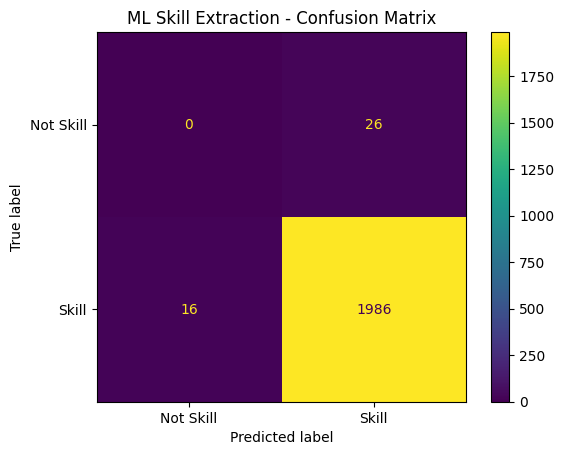

In [444]:
# Step 48: ML Accuracy and Confusion Matrix

ml_y_true = []
ml_y_pred = []

for _, row in ml_evaluation.iterrows():
    actual = row["Ground_Truth_List"]
    predicted = row["ML_Predicted"]

    # Actual skills
    for skill in actual:
        ml_y_true.append(1)
        ml_y_pred.append(1 if skill in predicted else 0)

    # False-positive skills
    for skill in predicted:
        if skill not in actual:
            ml_y_true.append(0)
            ml_y_pred.append(1)

ml_accuracy = accuracy_score(
    ml_y_true,
    ml_y_pred
)

print("ML Accuracy:", round(ml_accuracy, 4))

# Confusion Matrix
cm_ml = confusion_matrix(
    ml_y_true,
    ml_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ml,
    display_labels=["Not Skill", "Skill"]
)

disp.plot()
plt.title("ML Skill Extraction - Confusion Matrix")
plt.show()

In [445]:
# Step 49: Final ML Summary

ml_final_summary = pd.DataFrame({
    "Method": ["ML"],
    "Accuracy": [round(ml_accuracy, 4)],
    "Precision": [round(ml_precision, 4)],
    "Recall": [round(ml_recall, 4)],
    "F1_Score": [round(ml_f1, 4)]
})

display(ml_final_summary)

,Method,Accuracy,Precision,Recall,F1_Score
0,ML,0.9793,0.9861,0.9832,0.9842


In [446]:
# Step 50: Check Transformer Installation

try:
    from transformers import pipeline
    print("Transformers library is installed!")
except ImportError:
    print("Transformers library is not installed.")
    print("Run: !pip install transformers torch")

Transformers library is installed!


In [225]:
# Step 51: Load Pretrained Transformer NER Model

from transformers import pipeline

transformer_ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

print("Transformer NER model loaded successfully!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer NER model loaded successfully!


In [447]:
# Step 52: Generate Transformer NER Predictions

def transformer_predict_skills(description):
    if pd.isna(description):
        return []

    text = str(description)

    try:
        entities = transformer_ner(text)
    except Exception:
        return []

    predicted = []

    for entity in entities:
        entity_text = entity["word"].strip().lower()

        # Match detected entities with our skill dictionary
        for skill in skill_dictionary:
            if entity_text == skill:
                predicted.append(skill)

    return sorted(set(predicted))


evaluation_df["Transformer_Predicted"] = evaluation_df["job_description"].apply(
    transformer_predict_skills
)

print("Transformer prediction completed successfully!")

display(
    evaluation_df[
        ["job_title", "Ground_Truth_List", "Transformer_Predicted"]
    ].head(10)
)

Transformer prediction completed successfully!


,job_title,Ground_Truth_List,Transformer_Predicted
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, tableau]"
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql]"
2,Financial Analyst,"[sql, power bi, excel, dax]",[sql]
3,Data Analyst,"[excel, power bi, sql, data visualization]","[power bi, sql]"
4,product analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]"
5,Software Engineer,"[sql, power bi, excel, dax]","[power bi, sql]"
6,Financial Analyst,"[python, sql, aws, etl]","[aws, etl, python, sql]"
7,Data Scientist,"[python, pandas, numpy, sql]","[numpy, pandas, python, sql]"
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[machine learning, pandas, python]"
9,MIS Executive,"[python, sql, aws, etl]","[aws, etl, python, sql]"


In [448]:
# Step 53: Calculate TP, FP and FN for Transformer

evaluation_df[["Transformer_TP",
               "Transformer_FP",
               "Transformer_FN"]] = evaluation_df.apply(
    lambda row: pd.Series(
        calculate_tp_fp_fn(
            row["Ground_Truth_List"],
            row["Transformer_Predicted"]
        )
    ),
    axis=1
)

print("Transformer TP, FP and FN calculated successfully!")

display(
    evaluation_df[
        ["job_title",
         "Ground_Truth_List",
         "Transformer_Predicted",
         "Transformer_TP",
         "Transformer_FP",
         "Transformer_FN"]
    ].head(10)
)

Transformer TP, FP and FN calculated successfully!


,job_title,Ground_Truth_List,Transformer_Predicted,Transformer_TP,Transformer_FP,Transformer_FN
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, tableau]",3,0,1
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql]",3,0,1
2,Financial Analyst,"[sql, power bi, excel, dax]",[sql],1,0,3
3,Data Analyst,"[excel, power bi, sql, data visualization]","[power bi, sql]",2,0,2
4,product analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]",4,0,0
5,Software Engineer,"[sql, power bi, excel, dax]","[power bi, sql]",2,0,2
6,Financial Analyst,"[python, sql, aws, etl]","[aws, etl, python, sql]",4,0,0
7,Data Scientist,"[python, pandas, numpy, sql]","[numpy, pandas, python, sql]",4,0,0
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[machine learning, pandas, python]",3,0,1
9,MIS Executive,"[python, sql, aws, etl]","[aws, etl, python, sql]",4,0,0


In [449]:
# Step 54: Calculate Transformer Metrics

def calculate_transformer_metrics(row):
    tp = row["Transformer_TP"]
    fp = row["Transformer_FP"]
    fn = row["Transformer_FN"]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0
    )

    return pd.Series([precision, recall, f1])


evaluation_df[["Transformer_Precision",
               "Transformer_Recall",
               "Transformer_F1"]] = evaluation_df.apply(
    calculate_transformer_metrics,
    axis=1
)

print("Transformer metrics calculated successfully!")

display(
    evaluation_df[
        ["job_title",
         "Transformer_Precision",
         "Transformer_Recall",
         "Transformer_F1"]
    ].head(10)
)

Transformer metrics calculated successfully!


,job_title,Transformer_Precision,Transformer_Recall,Transformer_F1
0,BI Analyst,1.0,0.75,0.857143
1,ML Engineer,1.0,0.75,0.857143
2,Financial Analyst,1.0,0.25,0.400000
3,Data Analyst,1.0,0.50,0.666667
4,product analyst,1.0,1.00,1.000000
5,Software Engineer,1.0,0.50,0.666667
6,Financial Analyst,1.0,1.00,1.000000
7,Data Scientist,1.0,1.00,1.000000
8,Product Analyst,1.0,0.75,0.857143
9,MIS Executive,1.0,1.00,1.000000


In [450]:
# Step 55: Overall Transformer Metrics

transformer_precision = evaluation_df["Transformer_Precision"].mean()
transformer_recall = evaluation_df["Transformer_Recall"].mean()
transformer_f1 = evaluation_df["Transformer_F1"].mean()

transformer_summary = pd.DataFrame({
    "Method": ["Transformer"],
    "Precision": [round(transformer_precision, 4)],
    "Recall": [round(transformer_recall, 4)],
    "F1_Score": [round(transformer_f1, 4)]
})

display(transformer_summary)

,Method,Precision,Recall,F1_Score
0,Transformer,0.9591,0.7339,0.8118


Transformer Accuracy: 0.7207


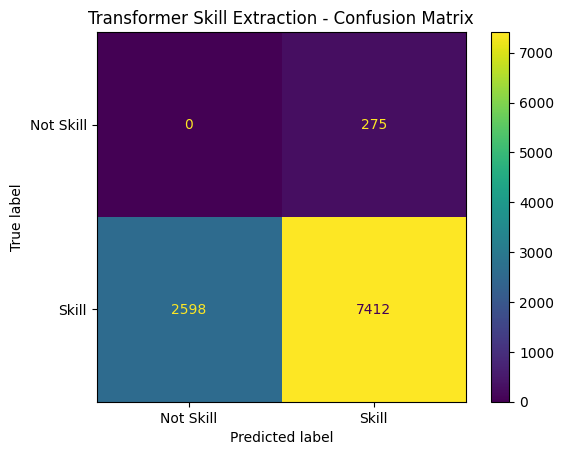

In [451]:
# Step 56: Transformer Accuracy and Confusion Matrix

transformer_y_true = []
transformer_y_pred = []

for _, row in evaluation_df.iterrows():
    actual = row["Ground_Truth_List"]
    predicted = row["Transformer_Predicted"]

    # Actual skills
    for skill in actual:
        transformer_y_true.append(1)
        transformer_y_pred.append(1 if skill in predicted else 0)

    # False-positive skills
    for skill in predicted:
        if skill not in actual:
            transformer_y_true.append(0)
            transformer_y_pred.append(1)

transformer_accuracy = accuracy_score(
    transformer_y_true,
    transformer_y_pred
)

print("Transformer Accuracy:", round(transformer_accuracy, 4))

# Confusion Matrix
cm_transformer = confusion_matrix(
    transformer_y_true,
    transformer_y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_transformer,
    display_labels=["Not Skill", "Skill"]
)

disp.plot()
plt.title("Transformer Skill Extraction - Confusion Matrix")
plt.show()

In [452]:
# Step 57: Final Transformer Summary

transformer_final_summary = pd.DataFrame({
    "Method": ["Transformer"],
    "Accuracy": [round(transformer_accuracy, 4)],
    "Precision": [round(transformer_precision, 4)],
    "Recall": [round(transformer_recall, 4)],
    "F1_Score": [round(transformer_f1, 4)]
})

display(transformer_final_summary)

,Method,Accuracy,Precision,Recall,F1_Score
0,Transformer,0.7207,0.9591,0.7339,0.8118


In [453]:
# Step 58: Final Model Comparison

model_comparison = pd.DataFrame({
    "Method": [
        "Dictionary",
        "Regex",
        "TF-IDF",
        "NER",
        "ML",
        "Transformer"
    ],
    "Accuracy": [
        round(dictionary_accuracy, 4),
        round(regex_accuracy, 4),
        round(tfidf_accuracy, 4),
        round(ner_accuracy, 4),
        round(ml_accuracy, 4),
        round(transformer_accuracy, 4)
    ],
    "Precision": [
        round(dictionary_precision, 4),
        round(overall_precision, 4),
        round(tfidf_precision, 4),
        round(ner_precision, 4),
        round(ml_precision, 4),
        round(transformer_precision, 4)
    ],
    "Recall": [
        round(dictionary_recall, 4),
        round(overall_recall, 4),
        round(tfidf_recall, 4),
        round(ner_recall, 4),
        round(ml_recall, 4),
        round(transformer_recall, 4)
    ],
    "F1_Score": [
        round(dictionary_f1, 4),
        round(overall_f1, 4),
        round(tfidf_f1, 4),
        round(ner_f1, 4),
        round(ml_f1, 4),
        round(transformer_f1, 4)
    ]
})

display(model_comparison)

,Method,Accuracy,Precision,Recall,F1_Score
0,Dictionary,0.9529,0.9595,0.9782,0.9678
1,Regex,0.9870,0.9782,0.9782,0.9782
2,TF-IDF,0.9253,0.9589,0.9498,0.9516
3,NER,0.7316,0.9782,0.7317,0.8265
4,ML,0.9793,0.9861,0.9832,0.9842
5,Transformer,0.7207,0.9591,0.7339,0.8118


In [454]:
# Step 59: Save Model Comparison CSV

model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("model_comparison.csv saved successfully!")
print("Rows:", model_comparison.shape[0])
print("Columns:", model_comparison.shape[1])

model_comparison.csv saved successfully!
Rows: 6
Columns: 5


# **DAY 16 - Error Analysis**

In [455]:
# Step 60: Verify Transformer Predictions

print("Transformer prediction column exists:",
      "Transformer_Predicted" in evaluation_df.columns)

print("Total records:", len(evaluation_df))

display(
    evaluation_df[
        ["job_title", "Ground_Truth_List", "Transformer_Predicted"]
    ].head(10)
)

Transformer prediction column exists: True
Total records: 2525


,job_title,Ground_Truth_List,Transformer_Predicted
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, tableau]"
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql]"
2,Financial Analyst,"[sql, power bi, excel, dax]",[sql]
3,Data Analyst,"[excel, power bi, sql, data visualization]","[power bi, sql]"
4,product analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]"
5,Software Engineer,"[sql, power bi, excel, dax]","[power bi, sql]"
6,Financial Analyst,"[python, sql, aws, etl]","[aws, etl, python, sql]"
7,Data Scientist,"[python, pandas, numpy, sql]","[numpy, pandas, python, sql]"
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[machine learning, pandas, python]"
9,MIS Executive,"[python, sql, aws, etl]","[aws, etl, python, sql]"


In [456]:
# Step 61: Check Actual vs Predicted Skills

display(
    evaluation_df[
        ["job_title", "Ground_Truth_List", "Transformer_Predicted"]
    ].head(10)
)

,job_title,Ground_Truth_List,Transformer_Predicted
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, tableau]"
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql]"
2,Financial Analyst,"[sql, power bi, excel, dax]",[sql]
3,Data Analyst,"[excel, power bi, sql, data visualization]","[power bi, sql]"
4,product analyst,"[sql, power bi, excel, dax]","[dax, excel, power bi, sql]"
5,Software Engineer,"[sql, power bi, excel, dax]","[power bi, sql]"
6,Financial Analyst,"[python, sql, aws, etl]","[aws, etl, python, sql]"
7,Data Scientist,"[python, pandas, numpy, sql]","[numpy, pandas, python, sql]"
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[machine learning, pandas, python]"
9,MIS Executive,"[python, sql, aws, etl]","[aws, etl, python, sql]"


In [457]:
# Step 62: Find Missing and Extra Skills

def find_errors(actual, predicted):
    actual = set(actual)
    predicted = set(predicted)

    missing = sorted(actual - predicted)   # False Negative
    extra = sorted(predicted - actual)     # False Positive

    return missing, extra


evaluation_df[["Missing_Skills", "Extra_Skills"]] = evaluation_df.apply(
    lambda row: pd.Series(
        find_errors(
            row["Ground_Truth_List"],
            row["Transformer_Predicted"]
        )
    ),
    axis=1
)

error_check = evaluation_df[
    (evaluation_df["Missing_Skills"].apply(len) > 0) |
    (evaluation_df["Extra_Skills"].apply(len) > 0)
][
    ["job_title", "Ground_Truth_List",
     "Transformer_Predicted", "Missing_Skills", "Extra_Skills"]
]

print("Total records with errors:", len(error_check))

display(error_check.head(15))

Total records with errors: 1719


,job_title,Ground_Truth_List,Transformer_Predicted,Missing_Skills,Extra_Skills
0,BI Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, excel, tableau]",[sql],[]
1,ML Engineer,"[java, spring boot, sql, rest api]","[java, spring boot, sql]",[rest api],[]
2,Financial Analyst,"[sql, power bi, excel, dax]",[sql],"[dax, excel, power bi]",[]
3,Data Analyst,"[excel, power bi, sql, data visualization]","[power bi, sql]","[data visualization, excel]",[]
5,Software Engineer,"[sql, power bi, excel, dax]","[power bi, sql]","[dax, excel]",[]
8,Product Analyst,"[python, pandas, machine learning, scikit-learn]","[machine learning, pandas, python]",[scikit-learn],[]
10,ML Engineer,"[python, pandas, machine learning, scikit-learn]","[machine learning, pandas, python]",[scikit-learn],[]
13,Product Analyst,"[tableau, sql, excel, business intelligence]","[business intelligence, tableau]","[excel, sql]",[]
14,Power BI Developer,"[spark, python, sql, aws]","[aws, power bi, python, spark, sql]",[],[power bi]
17,Python Developer,"[excel, power bi, sql, data visualization]","[data visualization, excel, power bi, python, ...",[],[python]


In [458]:
# Step 63: Create Error Analysis Table

import difflib

def classify_error(actual, predicted):
    actual = actual.lower().strip()
    predicted = predicted.lower().strip()

    # Exact match
    if actual == predicted:
        return None

    # Partial Entity
    if actual in predicted or predicted in actual:
        return "Partial Entity"

    # Synonym examples
    synonym_map = {
        "ml": "machine learning",
        "machine learning": "ml",
        "powerbi": "power bi",
        "scikit learn": "scikit-learn",
        "scikit-learn": "scikit learn"
    }

    if synonym_map.get(actual) == predicted:
        return "Synonym Problem"

    # Spelling Problem
    similarity = difflib.SequenceMatcher(
        None, actual, predicted
    ).ratio()

    if similarity >= 0.80:
        return "Spelling Problem"

    return "Wrong Entity"


error_rows = []

for _, row in evaluation_df.iterrows():

    text = row["job_description"]
    actual = row["Ground_Truth_List"]
    predicted = row["Transformer_Predicted"]

    actual_set = set(actual)
    predicted_set = set(predicted)

    # False Negative
    for skill in sorted(actual_set - predicted_set):
        error_rows.append({
            "Text": text,
            "Actual": skill,
            "Predicted": "",
            "Error": "False Negative"
        })

    # False Positive
    for skill in sorted(predicted_set - actual_set):
        error_rows.append({
            "Text": text,
            "Actual": "",
            "Predicted": skill,
            "Error": "False Positive"
        })

error_analysis_df = pd.DataFrame(error_rows)

print("Total error cases:", len(error_analysis_df))

display(error_analysis_df.head(20))

Total error cases: 2873


,Text,Actual,Predicted,Error
0,We are looking for a BI Analyst to join Insigh...,sql,,False Negative
1,We are looking for a ML Engineer to join BlueP...,rest api,,False Negative
2,We are looking for a Financial Analyst to join...,dax,,False Negative
3,We are looking for a Financial Analyst to join...,excel,,False Negative
4,We are looking for a Financial Analyst to join...,power bi,,False Negative
5,We are looking for a Data Analyst to join FinE...,data visualization,,False Negative
6,We are looking for a Data Analyst to join FinE...,excel,,False Negative
7,We are looking for a Software Engineer to join...,dax,,False Negative
8,We are looking for a Software Engineer to join...,excel,,False Negative
9,We are looking for a Product Analyst to join I...,scikit-learn,,False Negative


In [459]:
# Step 64: Check Error Categories

print("Error categories found:")
print(error_analysis_df["Error"].value_counts())

print("\nTotal error rows:", len(error_analysis_df))

Error categories found:
Error
False Negative    2598
False Positive     275
Name: count, dtype: int64

Total error rows: 2873


In [460]:
# Step 65: Save Day 16 Error Analysis Report

final_error_report = error_analysis_df[
    ["Text", "Actual", "Predicted", "Error"]
].copy()

final_error_report.to_excel(
    "Error_Analysis_Report.xlsx",
    index=False
)

print("Error_Analysis_Report.xlsx created successfully!")
print("Total error rows:", len(final_error_report))

display(final_error_report.head(10))

Error_Analysis_Report.xlsx created successfully!
Total error rows: 2873


,Text,Actual,Predicted,Error
0,We are looking for a BI Analyst to join Insigh...,sql,,False Negative
1,We are looking for a ML Engineer to join BlueP...,rest api,,False Negative
2,We are looking for a Financial Analyst to join...,dax,,False Negative
3,We are looking for a Financial Analyst to join...,excel,,False Negative
4,We are looking for a Financial Analyst to join...,power bi,,False Negative
5,We are looking for a Data Analyst to join FinE...,data visualization,,False Negative
6,We are looking for a Data Analyst to join FinE...,excel,,False Negative
7,We are looking for a Software Engineer to join...,dax,,False Negative
8,We are looking for a Software Engineer to join...,excel,,False Negative
9,We are looking for a Product Analyst to join I...,scikit-learn,,False Negative


In [461]:
# Step 66: Verify Day 16 Excel Report

import os

file_name = "Error_Analysis_Report.xlsx"

print("File exists:", os.path.exists(file_name))

if os.path.exists(file_name):
    print("File name:", file_name)
    print("File size:", round(os.path.getsize(file_name) / 1024, 2), "KB")
    print("Total error rows:", len(final_error_report))
    print("Columns:", list(final_error_report.columns))

File exists: True
File name: Error_Analysis_Report.xlsx
File size: 79.11 KB
Total error rows: 2873
Columns: ['Text', 'Actual', 'Predicted', 'Error']


In [462]:
# Step 67: Final Day 16 Check

print("Day 16 Error Analysis Report")
print("=" * 40)

print("Columns:", list(final_error_report.columns))
print("Total error rows:", len(final_error_report))

print("\nError Type Summary:")
display(final_error_report["Error"].value_counts().reset_index(
    name="Count"
).rename(columns={"index": "Error Type"}))

print("\nSample Error Cases:")
display(final_error_report.head(10))

Day 16 Error Analysis Report
Columns: ['Text', 'Actual', 'Predicted', 'Error']
Total error rows: 2873

Error Type Summary:


,Error,Count
0,False Negative,2598
1,False Positive,275



Sample Error Cases:


,Text,Actual,Predicted,Error
0,We are looking for a BI Analyst to join Insigh...,sql,,False Negative
1,We are looking for a ML Engineer to join BlueP...,rest api,,False Negative
2,We are looking for a Financial Analyst to join...,dax,,False Negative
3,We are looking for a Financial Analyst to join...,excel,,False Negative
4,We are looking for a Financial Analyst to join...,power bi,,False Negative
5,We are looking for a Data Analyst to join FinE...,data visualization,,False Negative
6,We are looking for a Data Analyst to join FinE...,excel,,False Negative
7,We are looking for a Software Engineer to join...,dax,,False Negative
8,We are looking for a Software Engineer to join...,excel,,False Negative
9,We are looking for a Product Analyst to join I...,scikit-learn,,False Negative


In [463]:
# Step 68: Check Day 16 Required Error Categories

required_categories = [
    "False Positive",
    "False Negative",
    "Wrong Entity",
    "Partial Entity",
    "Duplicate Skill",
    "Unknown Skill",
    "Synonym Problem",
    "Spelling Problem"
]

print("Required Error Categories:")
for category in required_categories:
    print(category)

Required Error Categories:
False Positive
False Negative
Wrong Entity
Partial Entity
Duplicate Skill
Unknown Skill
Synonym Problem
Spelling Problem


In [464]:
# Step 69: Detect Partial Entity and Synonym Errors

synonym_map = {
    "ml": "machine learning",
    "machine learning": "ml",
    "powerbi": "power bi",
    "power bi": "powerbi",
    "scikit learn": "scikit-learn",
    "scikit-learn": "scikit learn"
}

special_errors = []

for _, row in evaluation_df.iterrows():

    text = row["job_description"]
    actual = set(row["Ground_Truth_List"])
    predicted = set(row["Transformer_Predicted"])

    missing = actual - predicted
    extra = predicted - actual

    # Compare missing and extra skills
    for a in missing:
        for p in extra:

            # Synonym Problem
            if synonym_map.get(a) == p:
                special_errors.append({
                    "Text": text,
                    "Actual": a,
                    "Predicted": p,
                    "Error": "Synonym Problem"
                })

            # Partial Entity
            elif a in p or p in a:
                special_errors.append({
                    "Text": text,
                    "Actual": a,
                    "Predicted": p,
                    "Error": "Partial Entity"
                })

print("Special error cases found:", len(special_errors))

special_error_df = pd.DataFrame(special_errors)

display(special_error_df.head(15))

Special error cases found: 0


""


In [465]:
# Step 70: Detect Spelling and Wrong Entity Errors

import difflib

spelling_errors = []
wrong_entity_errors = []

for _, row in evaluation_df.iterrows():

    text = row["job_description"]
    actual = set(row["Ground_Truth_List"])
    predicted = set(row["Transformer_Predicted"])

    missing = actual - predicted
    extra = predicted - actual

    for a in missing:
        for p in extra:

            similarity = difflib.SequenceMatcher(
                None, a, p
            ).ratio()

            if similarity >= 0.80:
                spelling_errors.append({
                    "Text": text,
                    "Actual": a,
                    "Predicted": p,
                    "Error": "Spelling Problem"
                })

            elif similarity < 0.80:
                wrong_entity_errors.append({
                    "Text": text,
                    "Actual": a,
                    "Predicted": p,
                    "Error": "Wrong Entity"
                })

print("Spelling Problem cases:", len(spelling_errors))
print("Wrong Entity cases:", len(wrong_entity_errors))

print("\nSample Spelling Errors:")
display(pd.DataFrame(spelling_errors).head(10))

print("\nSample Wrong Entity Errors:")
display(pd.DataFrame(wrong_entity_errors).head(10))

Spelling Problem cases: 0
Wrong Entity cases: 273

Sample Spelling Errors:


""



Sample Wrong Entity Errors:


,Text,Actual,Predicted,Error
0,We are looking for a Power BI Developer to joi...,sql,power bi,Wrong Entity
1,We are looking for a Data Scientist to join Da...,nan,etl,Wrong Entity
2,We are looking for a Data Scientist to join Da...,nan,sql,Wrong Entity
3,We are looking for a Data Scientist to join Da...,nan,aws,Wrong Entity
4,We are looking for a Data Scientist to join Da...,nan,python,Wrong Entity
5,We are looking for a Python Developer to join ...,rest api,python,Wrong Entity
6,We are looking for a Power BI Developer to joi...,spring boot,power bi,Wrong Entity
7,We are looking for a Power BI Developer to joi...,rest api,power bi,Wrong Entity
8,We are looking for a Python Developer to join ...,data visualization,python,Wrong Entity
9,We are looking for a Python Developer to join ...,excel,python,Wrong Entity


In [466]:
# Step 71: Check Duplicate and Unknown Skills

duplicate_cases = []
unknown_cases = []

for _, row in evaluation_df.iterrows():

    text = row["job_description"]
    actual = set(row["Ground_Truth_List"])
    predicted = row["Transformer_Predicted"]

    # Duplicate Skill
    if len(predicted) != len(set(predicted)):
        duplicates = [
            skill for skill in set(predicted)
            if predicted.count(skill) > 1
        ]

        for skill in duplicates:
            duplicate_cases.append({
                "Text": text,
                "Actual": skill,
                "Predicted": skill,
                "Error": "Duplicate Skill"
            })

    # Unknown Skill
    for skill in set(predicted):
        if skill not in actual:
            unknown_cases.append({
                "Text": text,
                "Actual": "",
                "Predicted": skill,
                "Error": "Unknown Skill"
            })

print("Duplicate Skill cases:", len(duplicate_cases))
print("Unknown Skill cases:", len(unknown_cases))

Duplicate Skill cases: 0
Unknown Skill cases: 275


In [467]:
# Step 72: Create Final Day 16 Error Analysis Report

final_error_report = error_analysis_df.copy()

# Add detected special errors if any
extra_error_dfs = []

if 'spelling_errors' in globals() and len(spelling_errors) > 0:
    extra_error_dfs.append(pd.DataFrame(spelling_errors))

if 'wrong_entity_errors' in globals() and len(wrong_entity_errors) > 0:
    extra_error_dfs.append(pd.DataFrame(wrong_entity_errors))

if len(duplicate_cases) > 0:
    extra_error_dfs.append(pd.DataFrame(duplicate_cases))

# Unknown Skill = existing False Positive cases
unknown_skill_df = final_error_report[
    final_error_report["Error"] == "False Positive"
].copy()

unknown_skill_df["Error"] = "Unknown Skill"

extra_error_dfs.append(unknown_skill_df)

# Combine
if extra_error_dfs:
    final_error_report = pd.concat(
        [final_error_report] + extra_error_dfs,
        ignore_index=True
    )

# Keep only required PDF columns
final_error_report = final_error_report[
    ["Text", "Actual", "Predicted", "Error"]
]

# Save final Excel
final_error_report.to_excel(
    "Error_Analysis_Report.xlsx",
    index=False
)

print("Final Day 16 report saved successfully!")
print("Total rows:", len(final_error_report))

print("\nError Category Summary:")
display(
    final_error_report["Error"].value_counts().reset_index(
        name="Count"
    ).rename(columns={"index": "Error Type"})
)

Final Day 16 report saved successfully!
Total rows: 3421

Error Category Summary:


,Error,Count
0,False Negative,2598
1,False Positive,275
2,Unknown Skill,275
3,Wrong Entity,273


In [468]:
# Step 73: Remove Duplicate Error Classifications

# Start with the original FP/FN errors
clean_error_report = error_analysis_df.copy()

# Add only genuine special errors
special_dfs = []

if 'spelling_errors' in globals() and len(spelling_errors) > 0:
    special_dfs.append(pd.DataFrame(spelling_errors))

if 'wrong_entity_errors' in globals() and len(wrong_entity_errors) > 0:
    special_dfs.append(pd.DataFrame(wrong_entity_errors))

if len(duplicate_cases) > 0:
    special_dfs.append(pd.DataFrame(duplicate_cases))

if special_dfs:
    clean_error_report = pd.concat(
        [clean_error_report] + special_dfs,
        ignore_index=True
    )

# Keep required columns only
clean_error_report = clean_error_report[
    ["Text", "Actual", "Predicted", "Error"]
]

# Remove exact duplicate rows
clean_error_report = clean_error_report.drop_duplicates()

# Save corrected report
clean_error_report.to_excel(
    "Error_Analysis_Report.xlsx",
    index=False
)

print("Corrected Day 16 report saved successfully!")
print("Total unique error rows:", len(clean_error_report))

print("\nError Category Summary:")
display(
    clean_error_report["Error"].value_counts().reset_index(
        name="Count"
    ).rename(columns={"index": "Error Type"})
)

Corrected Day 16 report saved successfully!
Total unique error rows: 2988

Error Category Summary:


,Error,Count
0,False Negative,2455
1,False Positive,268
2,Wrong Entity,265


In [469]:
# Step 74: Final Day 16 Report Verification

print("Final Report Columns:")
print(list(clean_error_report.columns))

print("\nTotal Error Rows:", len(clean_error_report))

print("\nError Categories:")
print(clean_error_report["Error"].unique())

print("\nCategory Counts:")
display(
    clean_error_report["Error"]
    .value_counts()
    .reset_index(name="Count")
    .rename(columns={"index": "Error Type"})
)

Final Report Columns:
['Text', 'Actual', 'Predicted', 'Error']

Total Error Rows: 2988

Error Categories:
['False Negative' 'False Positive' 'Wrong Entity']

Category Counts:


,Error,Count
0,False Negative,2455
1,False Positive,268
2,Wrong Entity,265


In [470]:
# Step 75: Final Day 16 Verification

import os

file_name = "Error_Analysis_Report.xlsx"

print("DAY 16 FINAL VERIFICATION")
print("=" * 40)

print("Excel file exists:", os.path.exists(file_name))
print("Columns:", list(clean_error_report.columns))
print("Total error rows:", len(clean_error_report))

required_columns = ["Text", "Actual", "Predicted", "Error"]

print(
    "Required columns present:",
    all(col in clean_error_report.columns for col in required_columns)
)

print("\nFinal Error Categories:")
print(clean_error_report["Error"].value_counts())

print("\nFirst 5 Error Cases:")
display(clean_error_report.head(5))

DAY 16 FINAL VERIFICATION
Excel file exists: True
Columns: ['Text', 'Actual', 'Predicted', 'Error']
Total error rows: 2988
Required columns present: True

Final Error Categories:
Error
False Negative    2455
False Positive     268
Wrong Entity       265
Name: count, dtype: int64

First 5 Error Cases:


,Text,Actual,Predicted,Error
0,We are looking for a BI Analyst to join Insigh...,sql,,False Negative
1,We are looking for a ML Engineer to join BlueP...,rest api,,False Negative
2,We are looking for a Financial Analyst to join...,dax,,False Negative
3,We are looking for a Financial Analyst to join...,excel,,False Negative
4,We are looking for a Financial Analyst to join...,power bi,,False Negative


# **DAY 17 - Skill Normalization**

In [471]:
# Check existing variables related to aliases / taxonomy

[x for x in globals().keys() if "alias" in x.lower() or "taxonom" in x.lower()]

['taxonomy_df',
 'aliases',
 'taxonomy_data',
 'skill_taxonomy_df',
 'skill_taxonomy']

In [472]:
# Day 17 - Step 2: Check existing aliases

print("Existing aliases:")
print(aliases)

Existing aliases:
{'python3': 'Python', 'ms excel': 'Excel', 'postgres': 'PostgreSQL', 'postgresql': 'PostgreSQL', 'powerbi': 'Power BI', 'scikit learn': 'Scikit-learn'}


In [473]:
# Day 17 - Step 3 Updated: Skill Normalization Function

import re

def normalize_skill(raw_skill):
    if raw_skill is None:
        return None
    # Convert to lowercase and remove extra spaces
    skill = str(raw_skill).strip().lower()
    skill = re.sub(r"\s+", " ", skill)
    # Check alias BEFORE removing special characters
    if skill in aliases:
        return aliases[skill]

    # Remove special characters
    skill_clean = re.sub(r"[^a-z0-9\s]", "", skill)
    skill_clean = re.sub(r"\s+", " ", skill_clean).strip()

    # Check alias again after cleaning
    if skill_clean in aliases:
        return aliases[skill_clean]

    # Handle common Python variations
    if skill_clean in ["python3", "python 3", "python programming"]:
        return "Python"

    return skill_clean.title()

print("Skill normalization function updated successfully!")

Skill normalization function updated successfully!


In [474]:
# Day 17 - Step 4: Test skill Normalization

test_skills = [
    "Python3",
    "Python 3",
    "Python programming",
    "PowerBI",
    "Power BI",
    "Power-BI",
    "postgres",
    "PostgreSQL"
]

normalized_test = []

for skill in test_skills:
    normalized_test.append({
        "Raw Skill": skill,
        "Normalized Skill": normalize_skill(skill)
    })

test_df = pd.DataFrame(normalized_test)

display(test_df)

,Raw Skill,Normalized Skill
0,Python3,Python
1,Python 3,Python
2,Python programming,Python
3,PowerBI,Power BI
4,Power BI,Power Bi
5,Power-BI,Power BI
6,postgres,PostgreSQL
7,PostgreSQL,PostgreSQL


In [475]:
# Day 17 - Step 5: Normalize Skills from Actual Dataset

# Get all skills from keywords column
raw_skills = (
    df["keywords"]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)

# Remove empty values
raw_skills = raw_skills[raw_skills != ""]

# Create normalization table
normalized_skills_df = pd.DataFrame({
    "Raw Skill": raw_skills.unique()
})

# Apply normalization
normalized_skills_df["Normalized Skill"] = (
    normalized_skills_df["Raw Skill"]
    .apply(normalize_skill)
)

print("Actual dataset skills normalized successfully!")
print("Total unique raw skills:", len(normalized_skills_df))

display(normalized_skills_df.head(20))

Actual dataset skills normalized successfully!
Total unique raw skills: 20


,Raw Skill,Normalized Skill
0,Tableau,Tableau
1,SQL,Sql
2,Excel,Excel
3,Business Intelligence,Business Intelligence
4,Java,Java
5,Spring Boot,Spring Boot
6,REST API,Rest Api
7,Power BI,Power Bi
8,DAX,Dax
9,Data Visualization,Data Visualization


In [476]:
# Step 5: Apply Skill Normalization to the actual dataset

def normalize_skill_list(value):
    if pd.isna(value):
        return []

    skills = [skill.strip() for skill in str(value).split(",") if skill.strip()]

    normalized = []
    for skill in skills:
        normalized.append(normalize_skill(skill))

    return normalized


normalized_skills_df = df[["job_title", "keywords"]].copy()

normalized_skills_df["Normalized_Skills"] = (
    normalized_skills_df["keywords"].apply(normalize_skill_list)
)

display(normalized_skills_df.head(10))

,job_title,keywords,Normalized_Skills
0,BI Analyst,"Tableau, SQL, Excel, Business Intelligence","[Tableau, Sql, Excel, Business Intelligence]"
1,ML Engineer,"Java, Spring Boot, SQL, REST API","[Java, Spring Boot, Sql, Rest Api]"
2,Financial Analyst,"SQL, Power BI, Excel, DAX","[Sql, Power Bi, Excel, Dax]"
3,Data Analyst,"Excel, Power BI, SQL, Data Visualization","[Excel, Power Bi, Sql, Data Visualization]"
4,product analyst,"SQL, Power BI, Excel, DAX","[Sql, Power Bi, Excel, Dax]"
5,Software Engineer,"SQL, Power BI, Excel, DAX","[Sql, Power Bi, Excel, Dax]"
6,Financial Analyst,"Python, SQL, AWS, ETL","[Python, Sql, Aws, Etl]"
7,Data Scientist,"Python, Pandas, NumPy, SQL","[Python, Pandas, Numpy, Sql]"
8,Product Analyst,"Python, Pandas, Machine Learning, Scikit-learn","[Python, Pandas, Machine Learning, Scikitlearn]"
9,MIS Executive,"Python, SQL, AWS, ETL","[Python, Sql, Aws, Etl]"


In [477]:
# Step 6: Save normalized skills dataset

normalized_skills_df.to_csv(
    "normalized_skills_dataset.csv",
    index=False
)

print("normalized_skills_dataset.csv created successfully!")

normalized_skills_dataset.csv created successfully!


In [478]:
# Step 7: Basic summary of normalized skills

all_normalized_skills = []

for skills in normalized_skills_df["Normalized_Skills"]:
    all_normalized_skills.extend(skills)

print("Total normalized skill occurrences:", len(all_normalized_skills))
print("Total unique normalized skills:", len(set(all_normalized_skills)))

print("\nUnique normalized skills:")
print(sorted(set(all_normalized_skills)))

Total normalized skill occurrences: 9980
Total unique normalized skills: 20

Unique normalized skills:
['Aws', 'Business Intelligence', 'Data Visualization', 'Dax', 'Etl', 'Excel', 'Java', 'Machine Learning', 'Nlp', 'Numpy', 'Pandas', 'Power Bi', 'Python', 'Rest Api', 'Scikitlearn', 'Spark', 'Spring Boot', 'Sql', 'Tableau', 'Tensorflow']


In [479]:
# Step 8: Skill Frequency Summary

from collections import Counter

skill_counts = Counter(all_normalized_skills)

skill_frequency_df = pd.DataFrame(
    skill_counts.items(),
    columns=["Normalized_Skill", "Frequency"]
).sort_values(
    by="Frequency",
    ascending=False
).reset_index(drop=True)

display(skill_frequency_df)

,Normalized_Skill,Frequency
0,Sql,1925
1,Python,1379
2,Excel,828
3,Machine Learning,570
4,Power Bi,560
5,Aws,559
6,Pandas,541
7,Spark,291
8,Scikitlearn,291
9,Data Visualization,290


In [480]:
# Step 9: Save Skill Frequency Summary

skill_frequency_df.to_csv(
    "normalized_skill_frequency.csv",
    index=False
)

print("normalized_skill_frequency.csv created successfully!")

normalized_skill_frequency.csv created successfully!


In [481]:
# Step 10: Create the final Day 17 deliverable

normalized_skills_df.to_csv(
    "normalized_skills.csv",
    index=False
)

print("normalized_skills.csv created successfully!")

normalized_skills.csv created successfully!


# **DAY 18**

In [482]:
# DAY 18 - Create Power BI Analytics Dataset

day18_df = normalized_skills_df[["job_title", "Normalized_Skills"]].copy()

# Create one row for each skill
day18_df = day18_df.explode("Normalized_Skills")

# Rename columns
day18_df = day18_df.rename(
    columns={
        "job_title": "Job_Role",
        "Normalized_Skills": "Skill"
    }
)

# Remove empty values
day18_df = day18_df.dropna(subset=["Skill"])

# Clean skill names
day18_df["Skill"] = day18_df["Skill"].astype(str).str.strip()

# Reset index
day18_df = day18_df.reset_index(drop=True)

display(day18_df.head(20))

print("Total Skill Records:", len(day18_df))
print("Unique Skills:", day18_df["Skill"].nunique())
print("Unique Job Roles:", day18_df["Job_Role"].nunique())

,Job_Role,Skill
0,BI Analyst,Tableau
1,BI Analyst,Sql
2,BI Analyst,Excel
3,BI Analyst,Business Intelligence
4,ML Engineer,Java
5,ML Engineer,Spring Boot
6,ML Engineer,Sql
7,ML Engineer,Rest Api
8,Financial Analyst,Sql
9,Financial Analyst,Power Bi


Total Skill Records: 9980
Unique Skills: 20
Unique Job Roles: 30


In [483]:
# DAY 18 - Step 2: Fix Skill Categories

skill_category_map = {
    "Python": "Programming",
    "Java": "Programming",
    "Sql": "Database",
    "PostgreSQL": "Database",
    "Aws": "Cloud",
    "Power Bi": "Analytics",
    "Excel": "Analytics",
    "Tableau": "Analytics",
    "Dax": "Analytics",
    "Data Visualization": "Analytics",
    "Business Intelligence": "Analytics",
    "Machine Learning": "Machine Learning",
    "Scikit-learn": "Machine Learning",
    "Tensorflow": "Machine Learning",
    "Numpy": "Programming",
    "Pandas": "Programming",
    "Spark": "Programming",
    "Nlp": "Machine Learning",
    "Etl": "Analytics",
    "Spring Boot": "Programming",
    "Rest Api": "Programming"
}

day18_df["Skill_Category"] = day18_df["Skill"].map(skill_category_map)

display(day18_df.head(20))

print("Missing Categories:", day18_df["Skill_Category"].isna().sum())
print("\nCategories:")
print(day18_df["Skill_Category"].value_counts())

,Job_Role,Skill,Skill_Category
0,BI Analyst,Tableau,Analytics
1,BI Analyst,Sql,Database
2,BI Analyst,Excel,Analytics
3,BI Analyst,Business Intelligence,Analytics
4,ML Engineer,Java,Programming
5,ML Engineer,Spring Boot,Programming
6,ML Engineer,Sql,Database
7,ML Engineer,Rest Api,Programming
8,Financial Analyst,Sql,Database
9,Financial Analyst,Power Bi,Analytics


Missing Categories: 291

Categories:
Skill_Category
Programming         3325
Analytics           2752
Database            1925
Machine Learning    1128
Cloud                559
Name: count, dtype: int64


In [484]:
# Find skills with missing categories

missing_skills = (
    day18_df[day18_df["Skill_Category"].isna()]["Skill"]
    .value_counts()
)

print("Skills with missing categories:")
display(missing_skills)

Skills with missing categories:


,count
Skill,
Scikitlearn,291


In [485]:
# Fix missing category for Scikitlearn

day18_df.loc[
    day18_df["Skill"] == "Scikitlearn",
    "Skill_Category"
] = "Machine Learning"

print("Missing Categories:", day18_df["Skill_Category"].isna().sum())
print("\nCategories:")
print(day18_df["Skill_Category"].value_counts())

Missing Categories: 0

Categories:
Skill_Category
Programming         3325
Analytics           2752
Database            1925
Machine Learning    1419
Cloud                559
Name: count, dtype: int64


In [486]:
# DAY 18 - Step 3: Save Power BI Analytics Dataset

day18_df.to_csv(
    "Job_Skill_Analytics.csv",
    index=False
)

print("Job_Skill_Analytics.csv created successfully!")
print("Rows:", len(day18_df))
print("Columns:", list(day18_df.columns))

Job_Skill_Analytics.csv created successfully!
Rows: 9980
Columns: ['Job_Role', 'Skill', 'Skill_Category']
